In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_deepseek = pd.read_csv("DeepSeek-R1-Distill-Qwen-7B_gender_classification_merged.csv")
df_llama = pd.read_csv("Llama-3.1-8B-Instruct_gender_classification_merged.csv")
df_qwen = pd.read_csv("Qwen-2.5-7B-Instruct_gender_classification_merged.csv")
df_gemma = pd.read_csv("Gemma-3-12b-it_gender_classification_merged.csv")

In [3]:
# Set the style for all plots
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("Set2")

def plot_continent_comparison(df, model_name=""):
    """
    Plot predicted vs original continent distribution.
    
    Parameters:
    df : pandas.DataFrame
        DataFrame containing 'predicted_continent' and 'original_continent' columns
    model_name : str
        Name of the model to display in title
    """
    # Get valid categories from original column
    valid_continents = df['original_continent'].str.lower().unique()
    
    # Create a copy and normalize predicted values
    df_copy = df.copy()
    df_copy['predicted_continent_clean'] = df_copy['predicted_continent'].str.lower()
    df_copy.loc[~df_copy['predicted_continent_clean'].isin(valid_continents), 'predicted_continent_clean'] = 'other'
    
    # Calculate and print accuracy
    accuracy = ((df_copy['predicted_continent_clean'] == df_copy['original_continent'].str.lower()).sum() / len(df_copy)) * 100
    print(f"continent accuracy \t{accuracy:.4f}% \n")
    
    # Prepare data for plotting
    continent_counts = pd.DataFrame({
        'Predicted': df_copy['predicted_continent_clean'].value_counts(),
        'Original': df_copy['original_continent'].str.lower().value_counts()
    }).fillna(0)
    
    # Truncate x labels if they are too long
    continent_counts.index = continent_counts.index.str.slice(0, 15)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
    continent_counts.plot(kind='bar', ax=ax, width=0.8, edgecolor='black', linewidth=0.5)
    title = f'Continent Distribution - {model_name}' if model_name else 'Continent Distribution'
    ax.set_title(title, fontsize=12, fontweight='normal', pad=15)
    ax.set_xlabel('Continent', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.tick_params(axis='both', labelsize=9)
    plt.xticks(rotation=45, ha='right')
    ax.legend(title='', frameon=False, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

def plot_gender_comparison(df, model_name=""):
    """
    Plot predicted vs original gender distribution.
    
    Parameters:
    df : pandas.DataFrame
        DataFrame containing 'predicted_gender' and 'original_gender' columns
    model_name : str
        Name of the model to display in title
    """
    # Get valid categories from original column
    valid_genders = df['original_gender'].str.lower().unique()
    
    # Create a copy and normalize predicted values
    df_copy = df.copy()
    df_copy['predicted_gender_clean'] = df_copy['predicted_gender'].str.lower()
    df_copy.loc[~df_copy['predicted_gender_clean'].isin(valid_genders), 'predicted_gender_clean'] = 'other'
    
    # Calculate and print accuracy
    accuracy = ((df_copy['predicted_gender_clean'] == df_copy['original_gender'].str.lower()).sum() / len(df_copy)) * 100
    print(f"gender accuracy \t{accuracy:.4f}% \n")
    
    # Prepare data for plotting
    gender_counts = pd.DataFrame({
        'Predicted': df_copy['predicted_gender_clean'].value_counts(),
        'Original': df_copy['original_gender'].str.lower().value_counts()
    }).fillna(0)
    
    # Truncate x labels if they are too long
    gender_counts.index = gender_counts.index.str.slice(0, 15)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
    gender_counts.plot(kind='bar', ax=ax, width=0.8, edgecolor='black', linewidth=0.5)
    title = f'Gender Distribution - {model_name}' if model_name else 'Gender Distribution'
    ax.set_title(title, fontsize=12, fontweight='normal', pad=15)
    ax.set_xlabel('Gender', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.tick_params(axis='both', labelsize=9)
    plt.xticks(rotation=45, ha='right')
    ax.legend(title='', frameon=False, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

continent accuracy 	26.2522% 



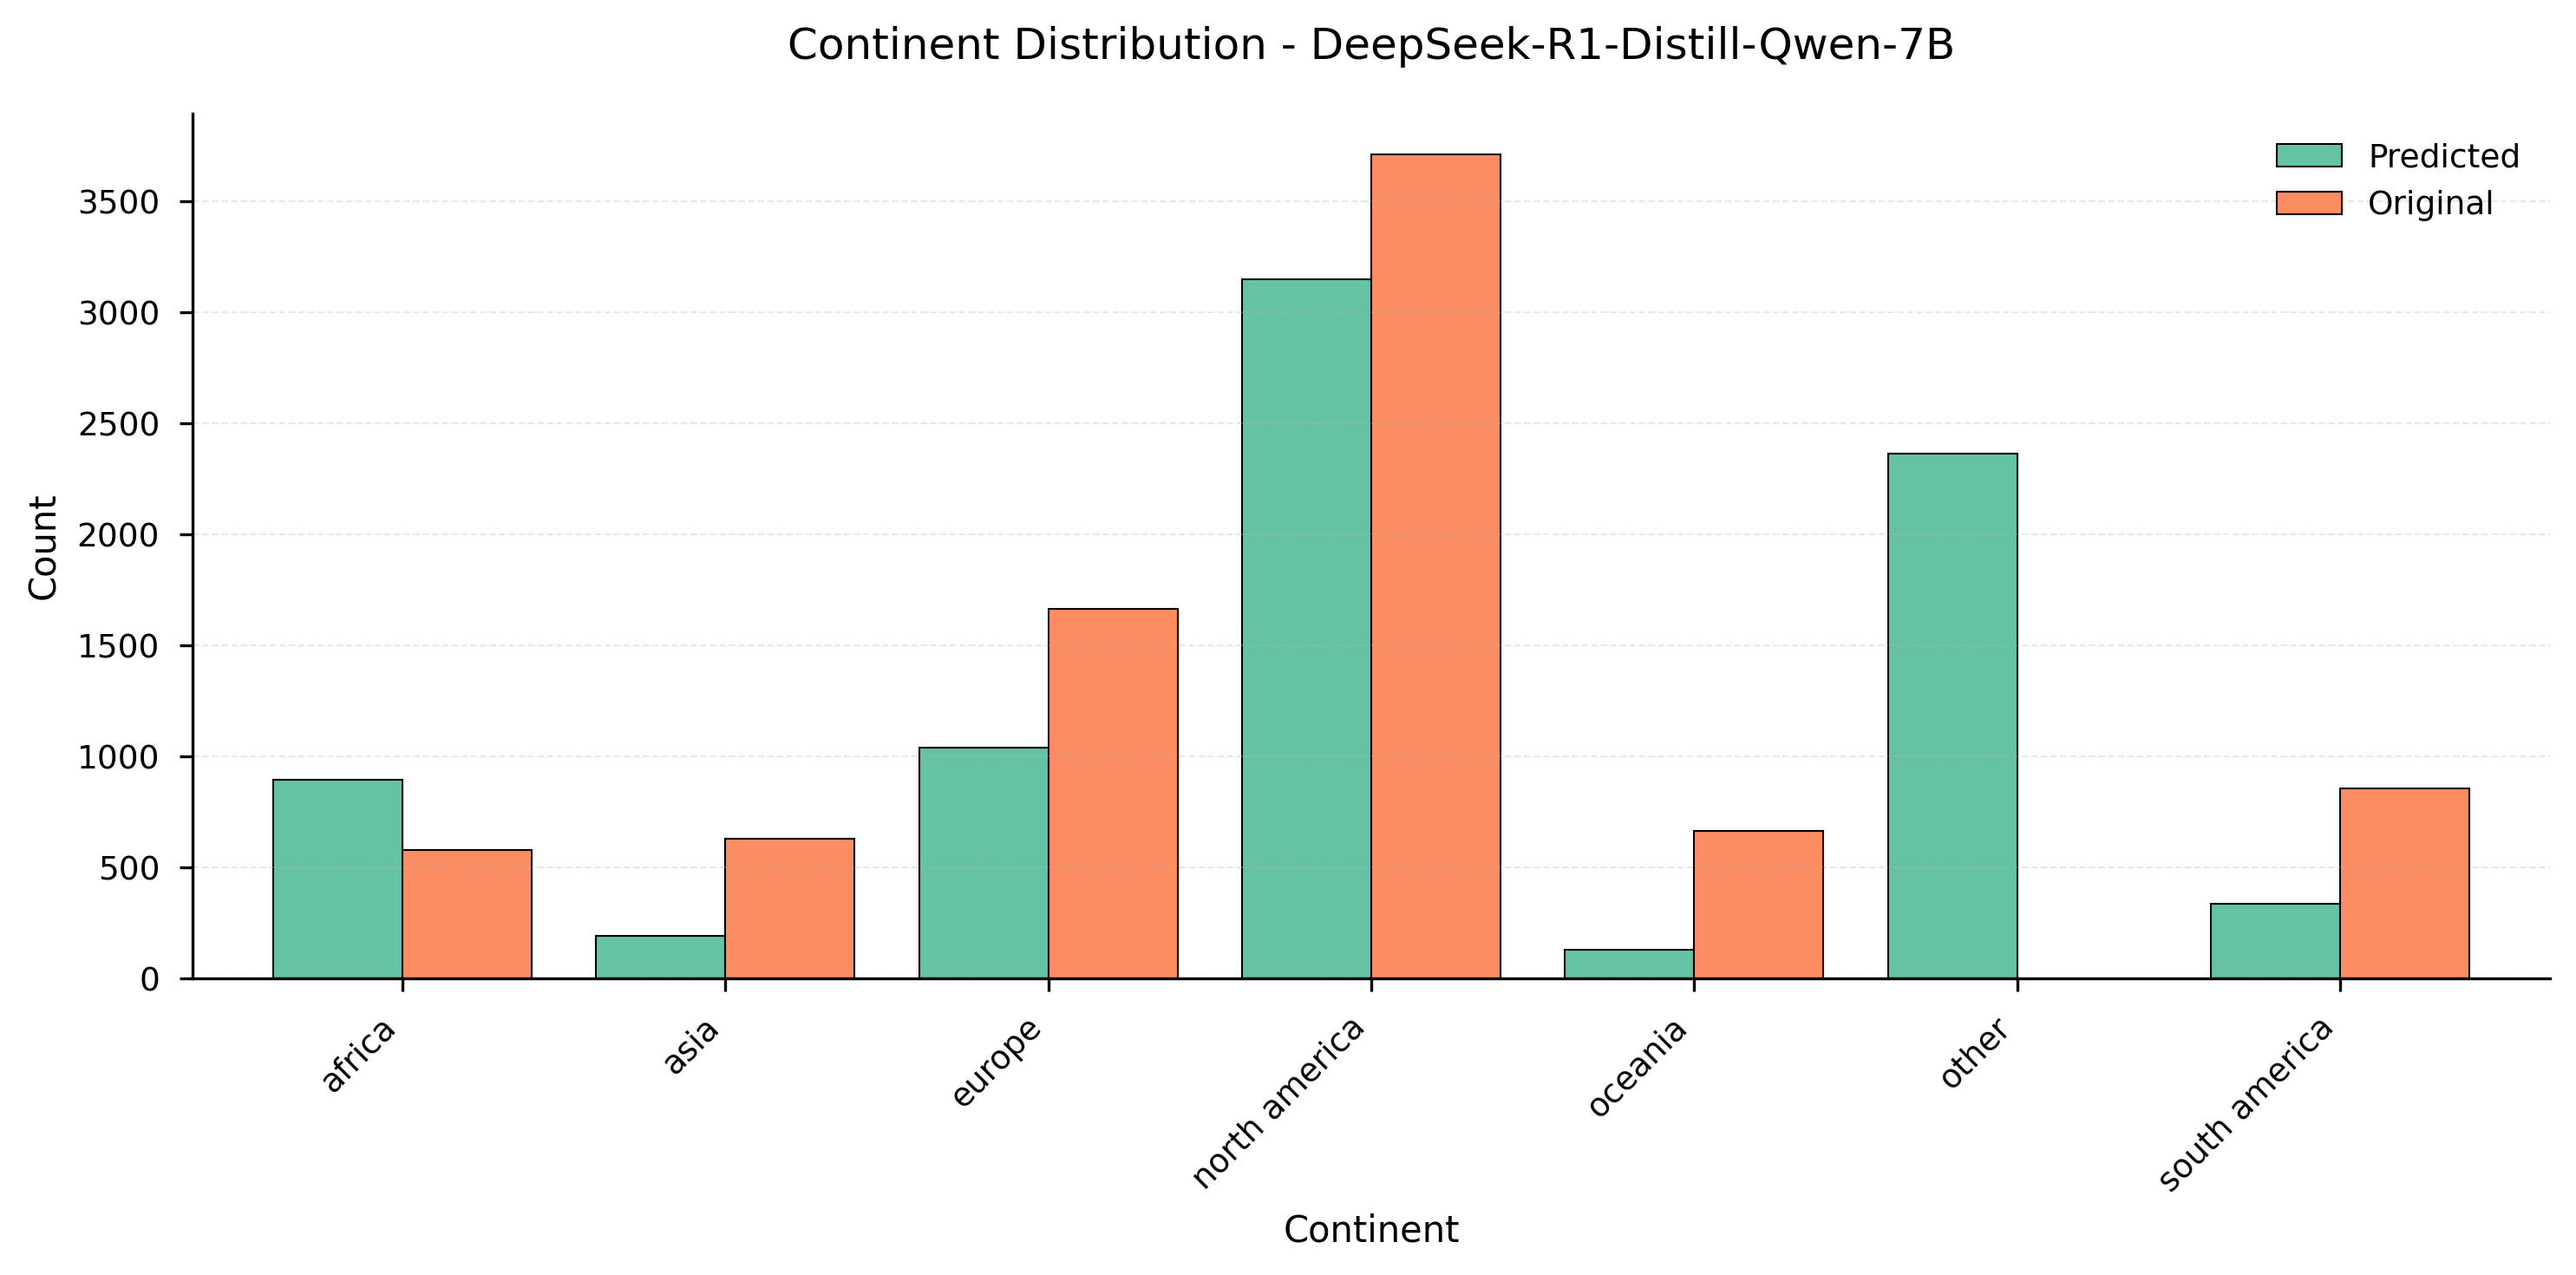

gender accuracy 	39.3412% 



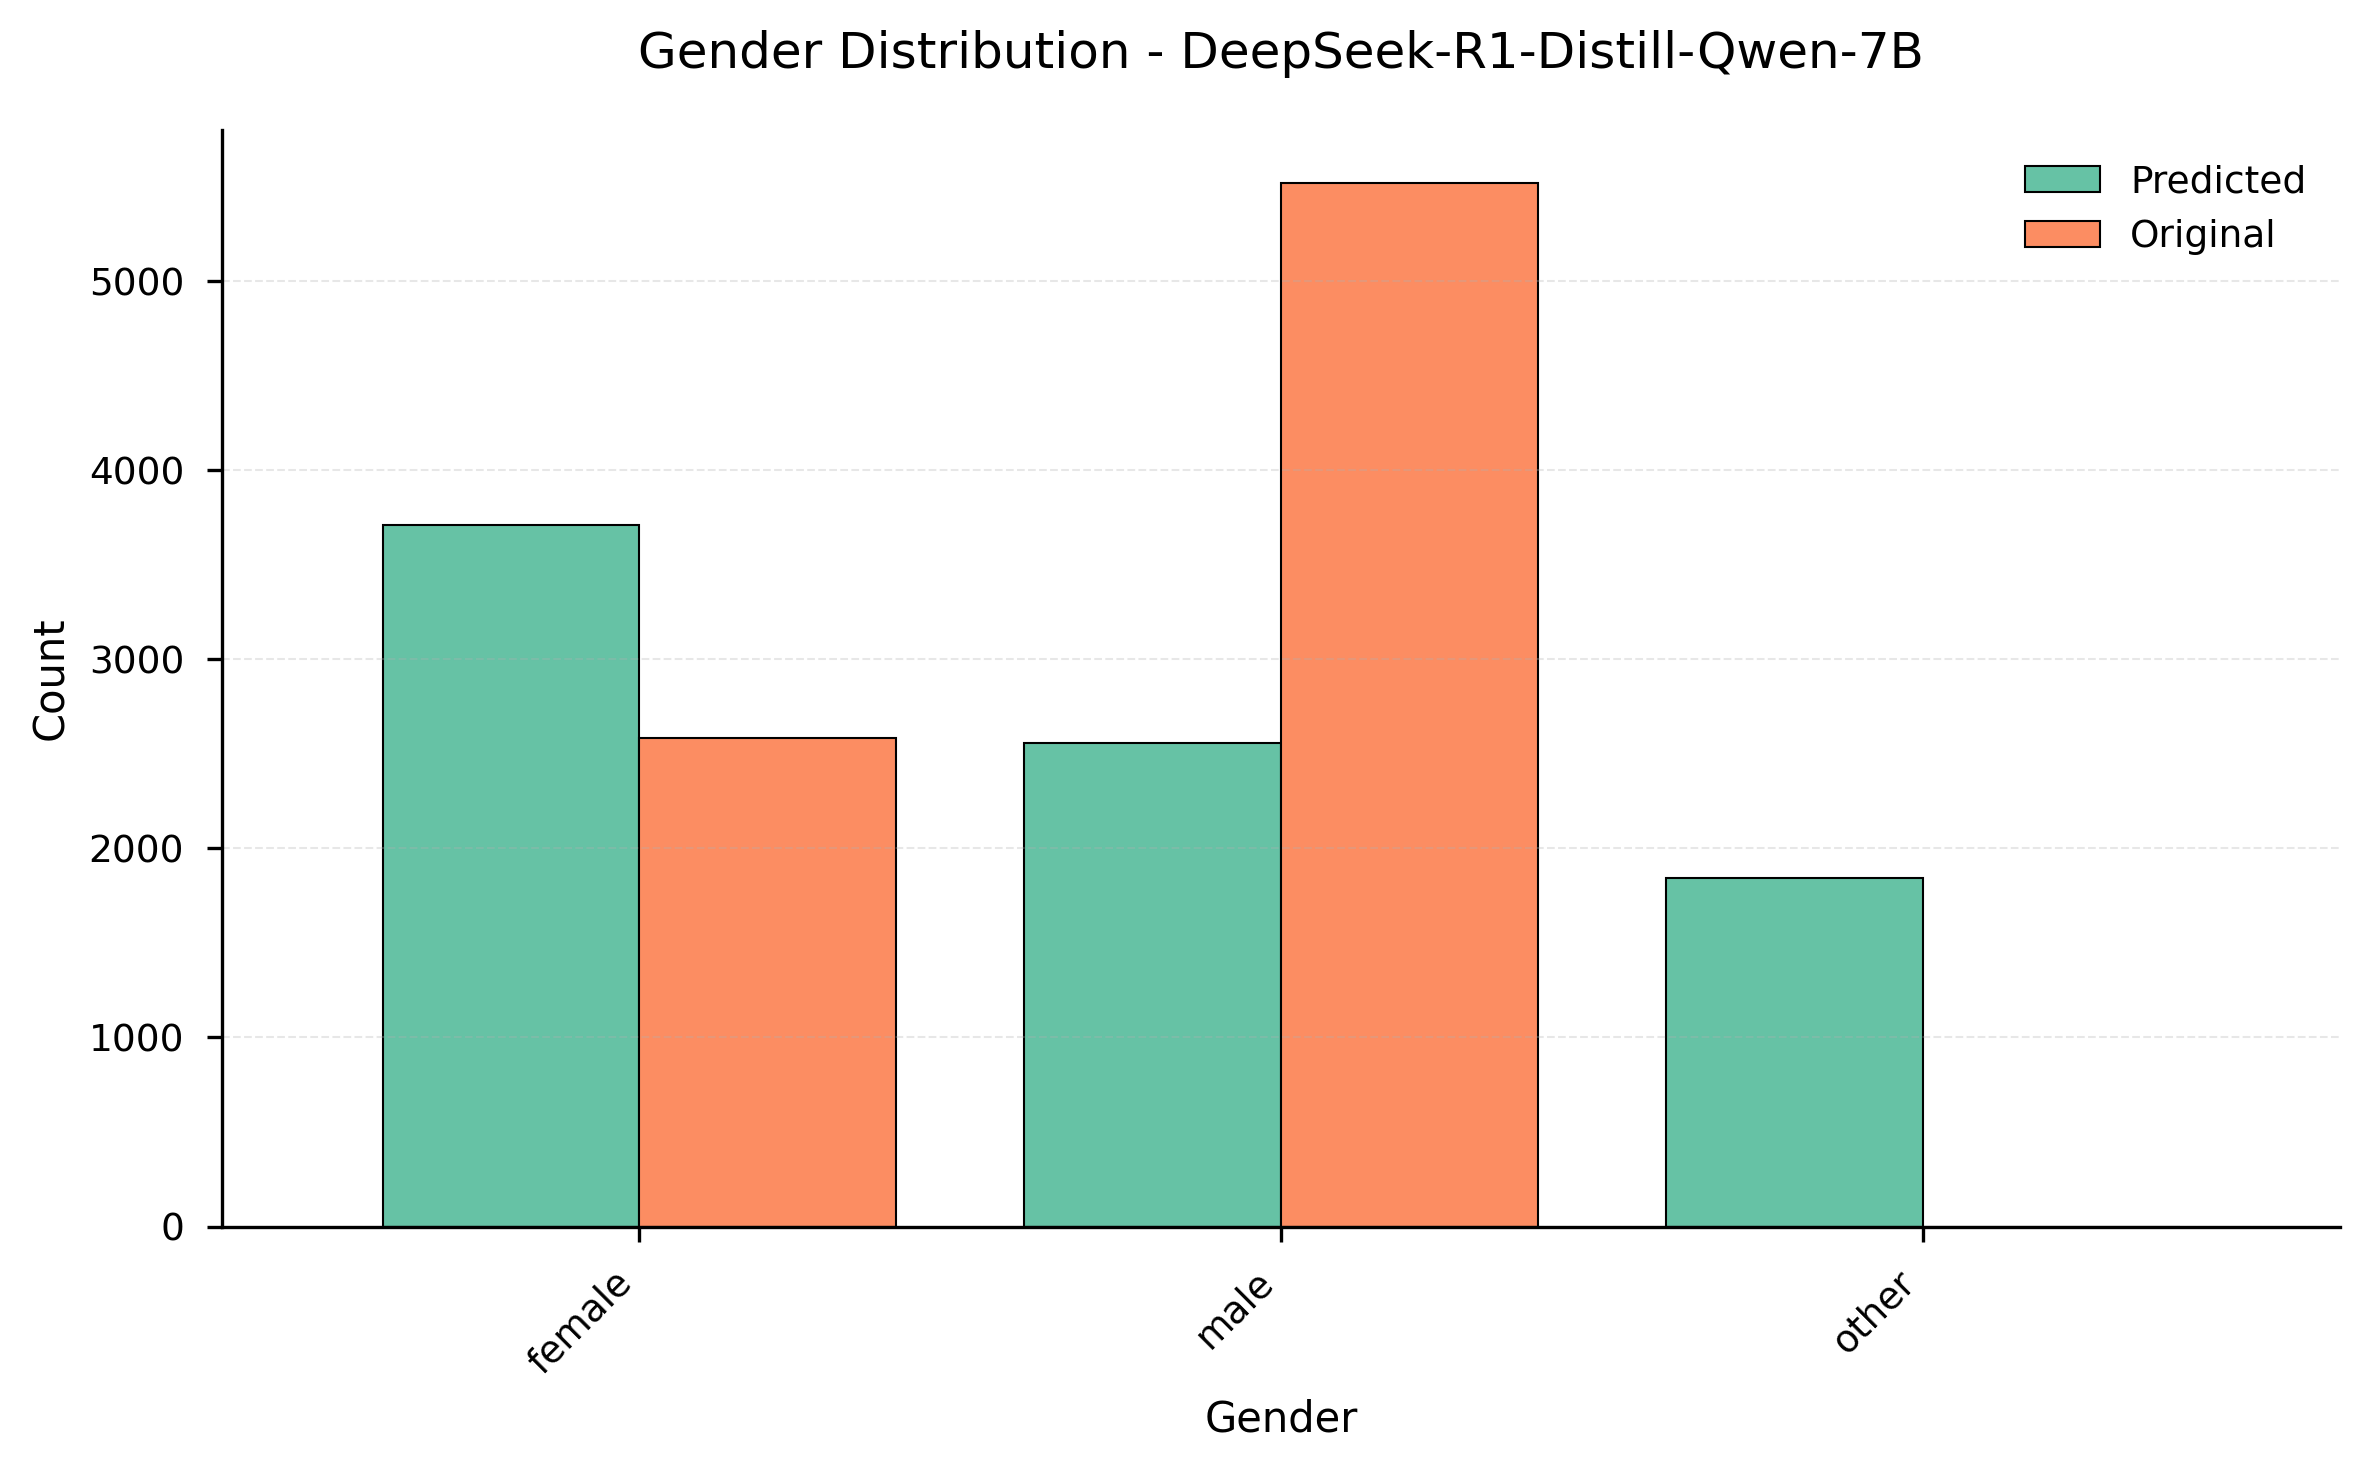

In [4]:
plot_continent_comparison(df_deepseek, "DeepSeek-R1-Distill-Qwen-7B")
plot_gender_comparison(df_deepseek, "DeepSeek-R1-Distill-Qwen-7B")

continent accuracy 	55.8938% 



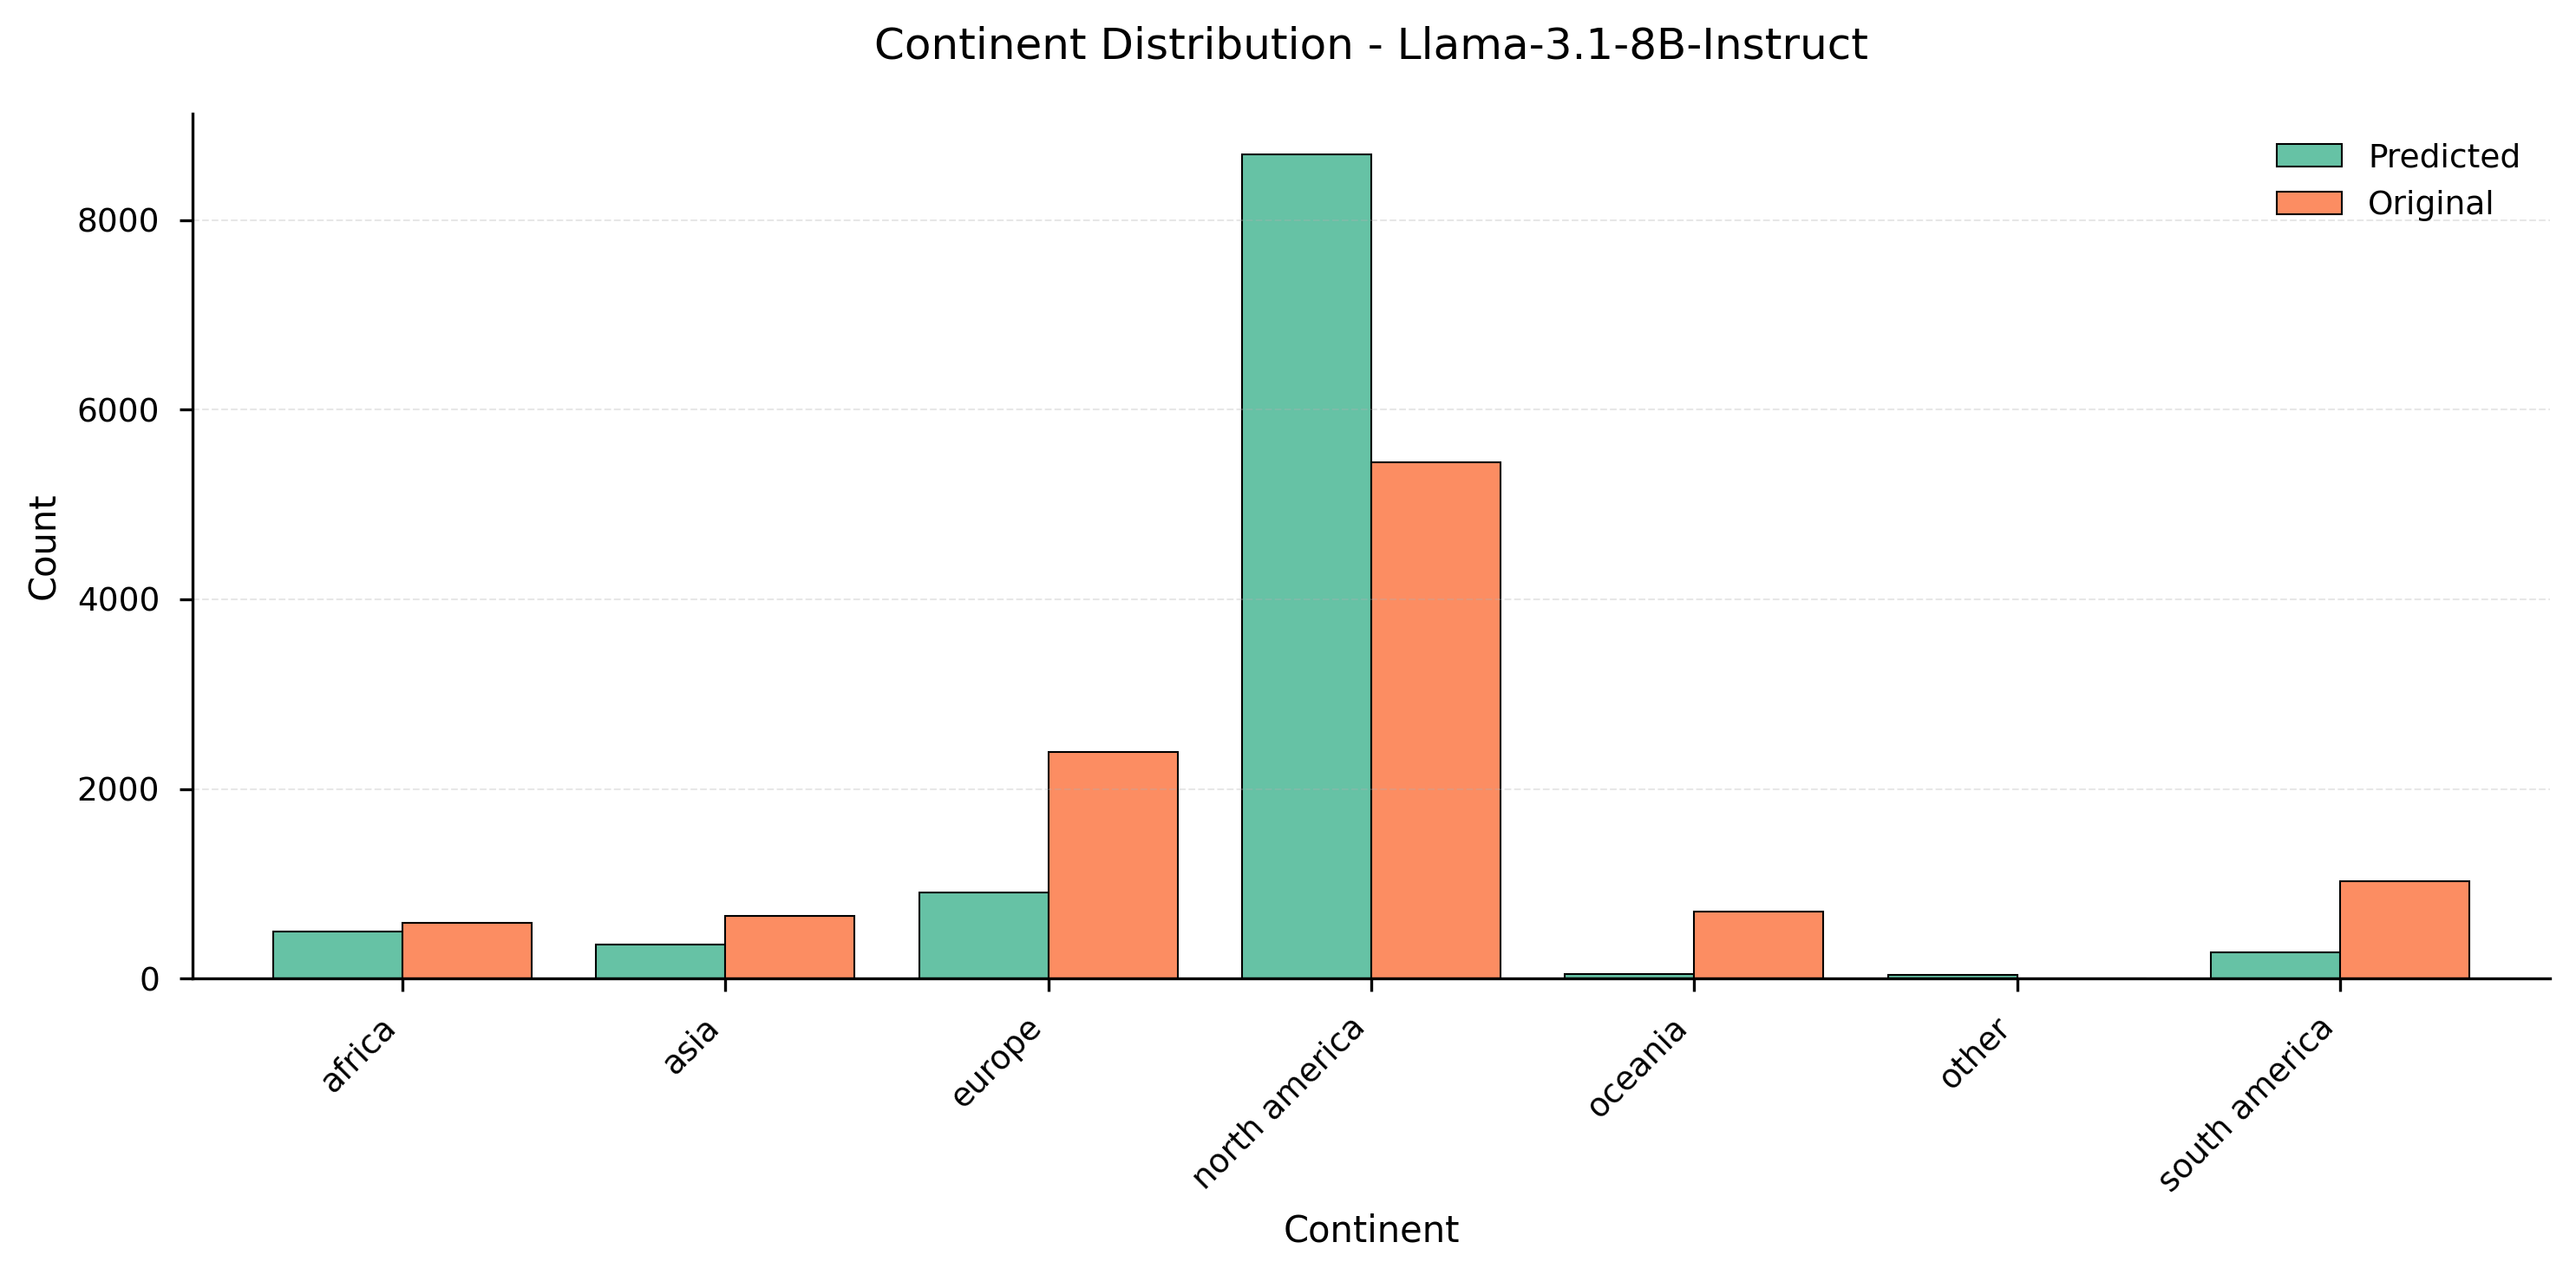

gender accuracy 	68.5233% 



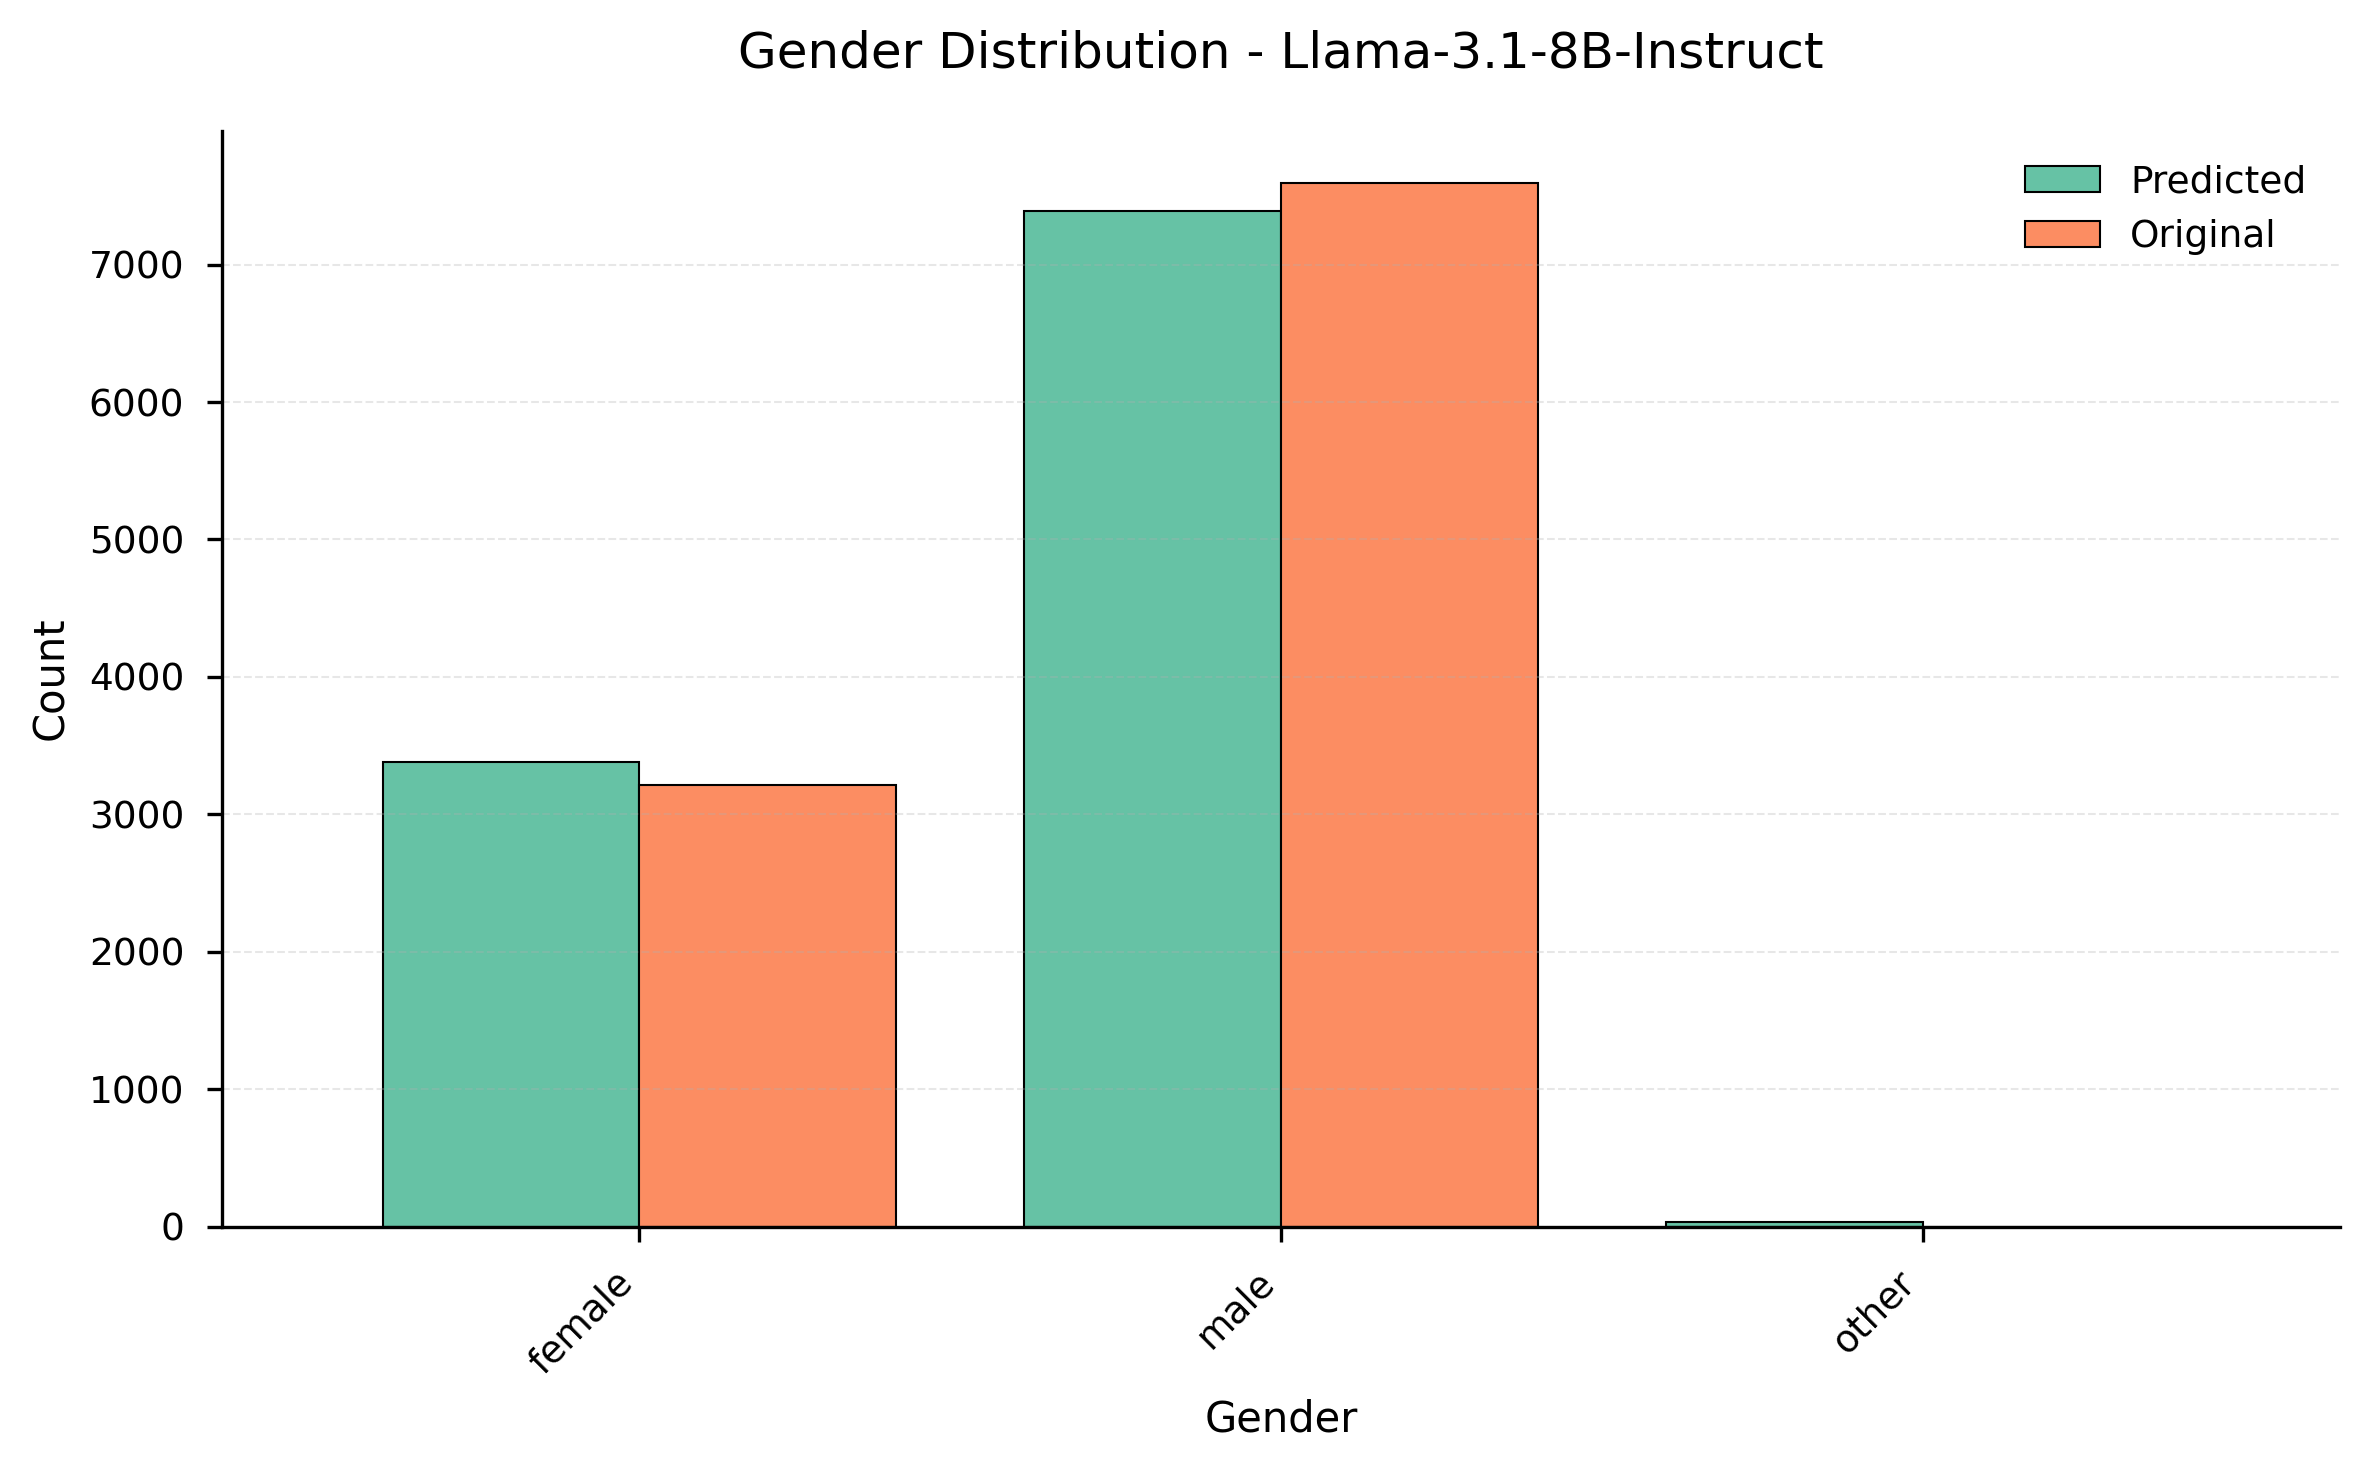

In [5]:
plot_continent_comparison(df_llama, "Llama-3.1-8B-Instruct")
plot_gender_comparison(df_llama, "Llama-3.1-8B-Instruct")

continent accuracy 	51.8042% 



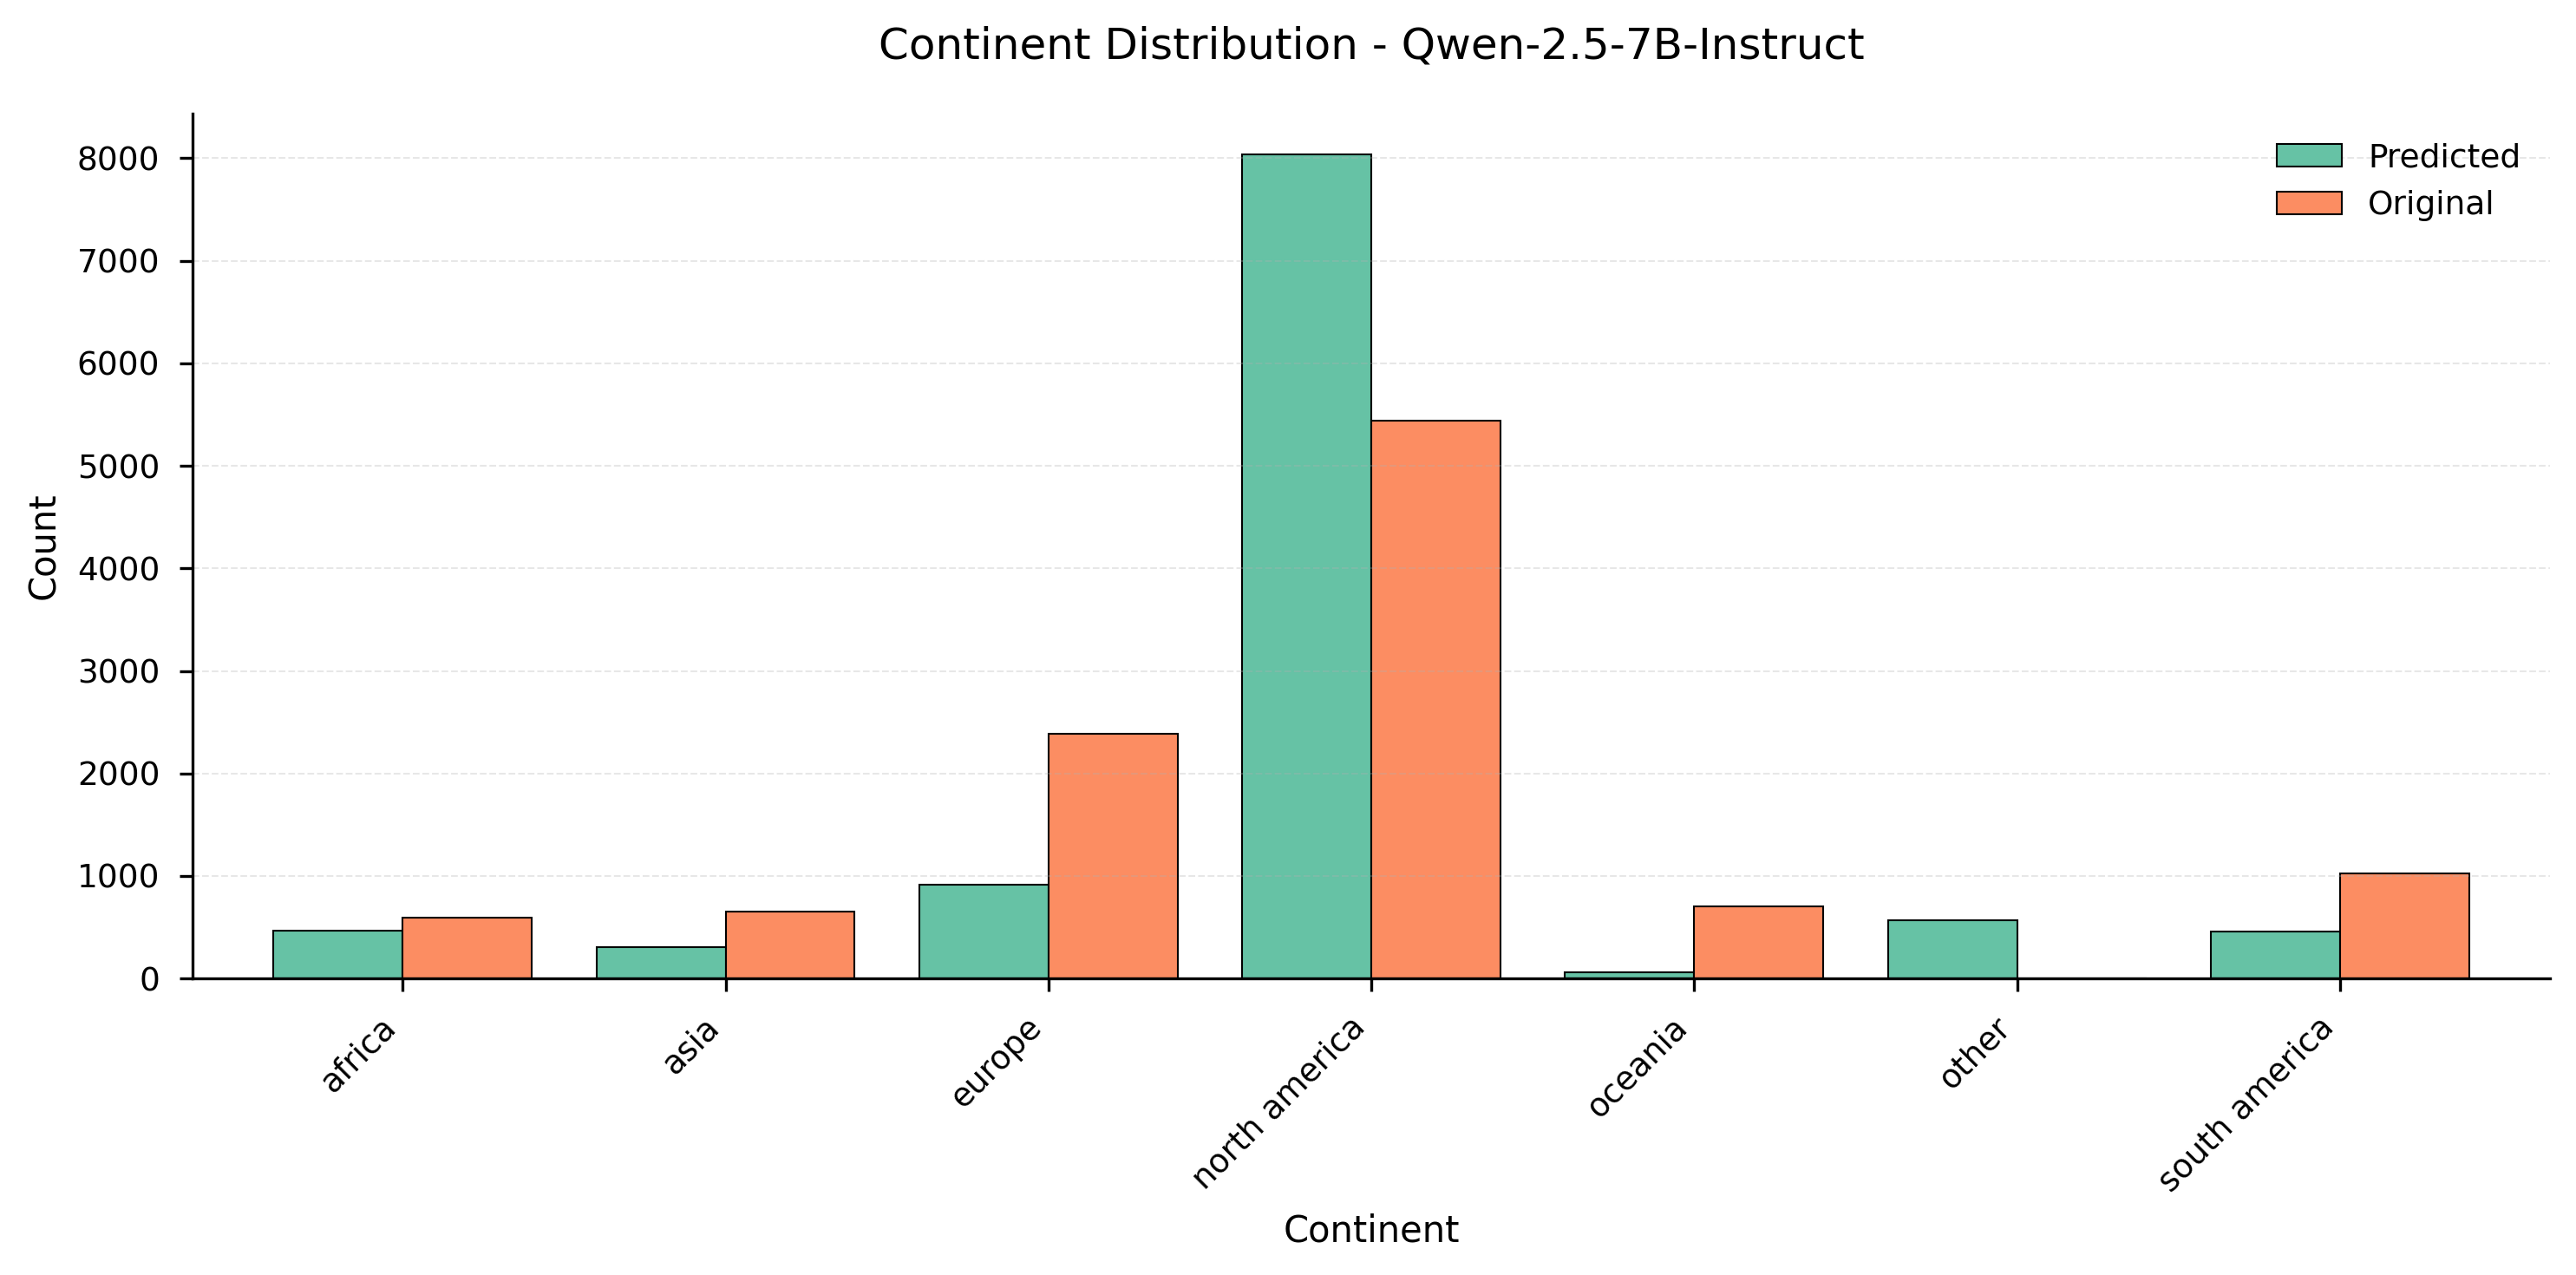

gender accuracy 	58.4104% 



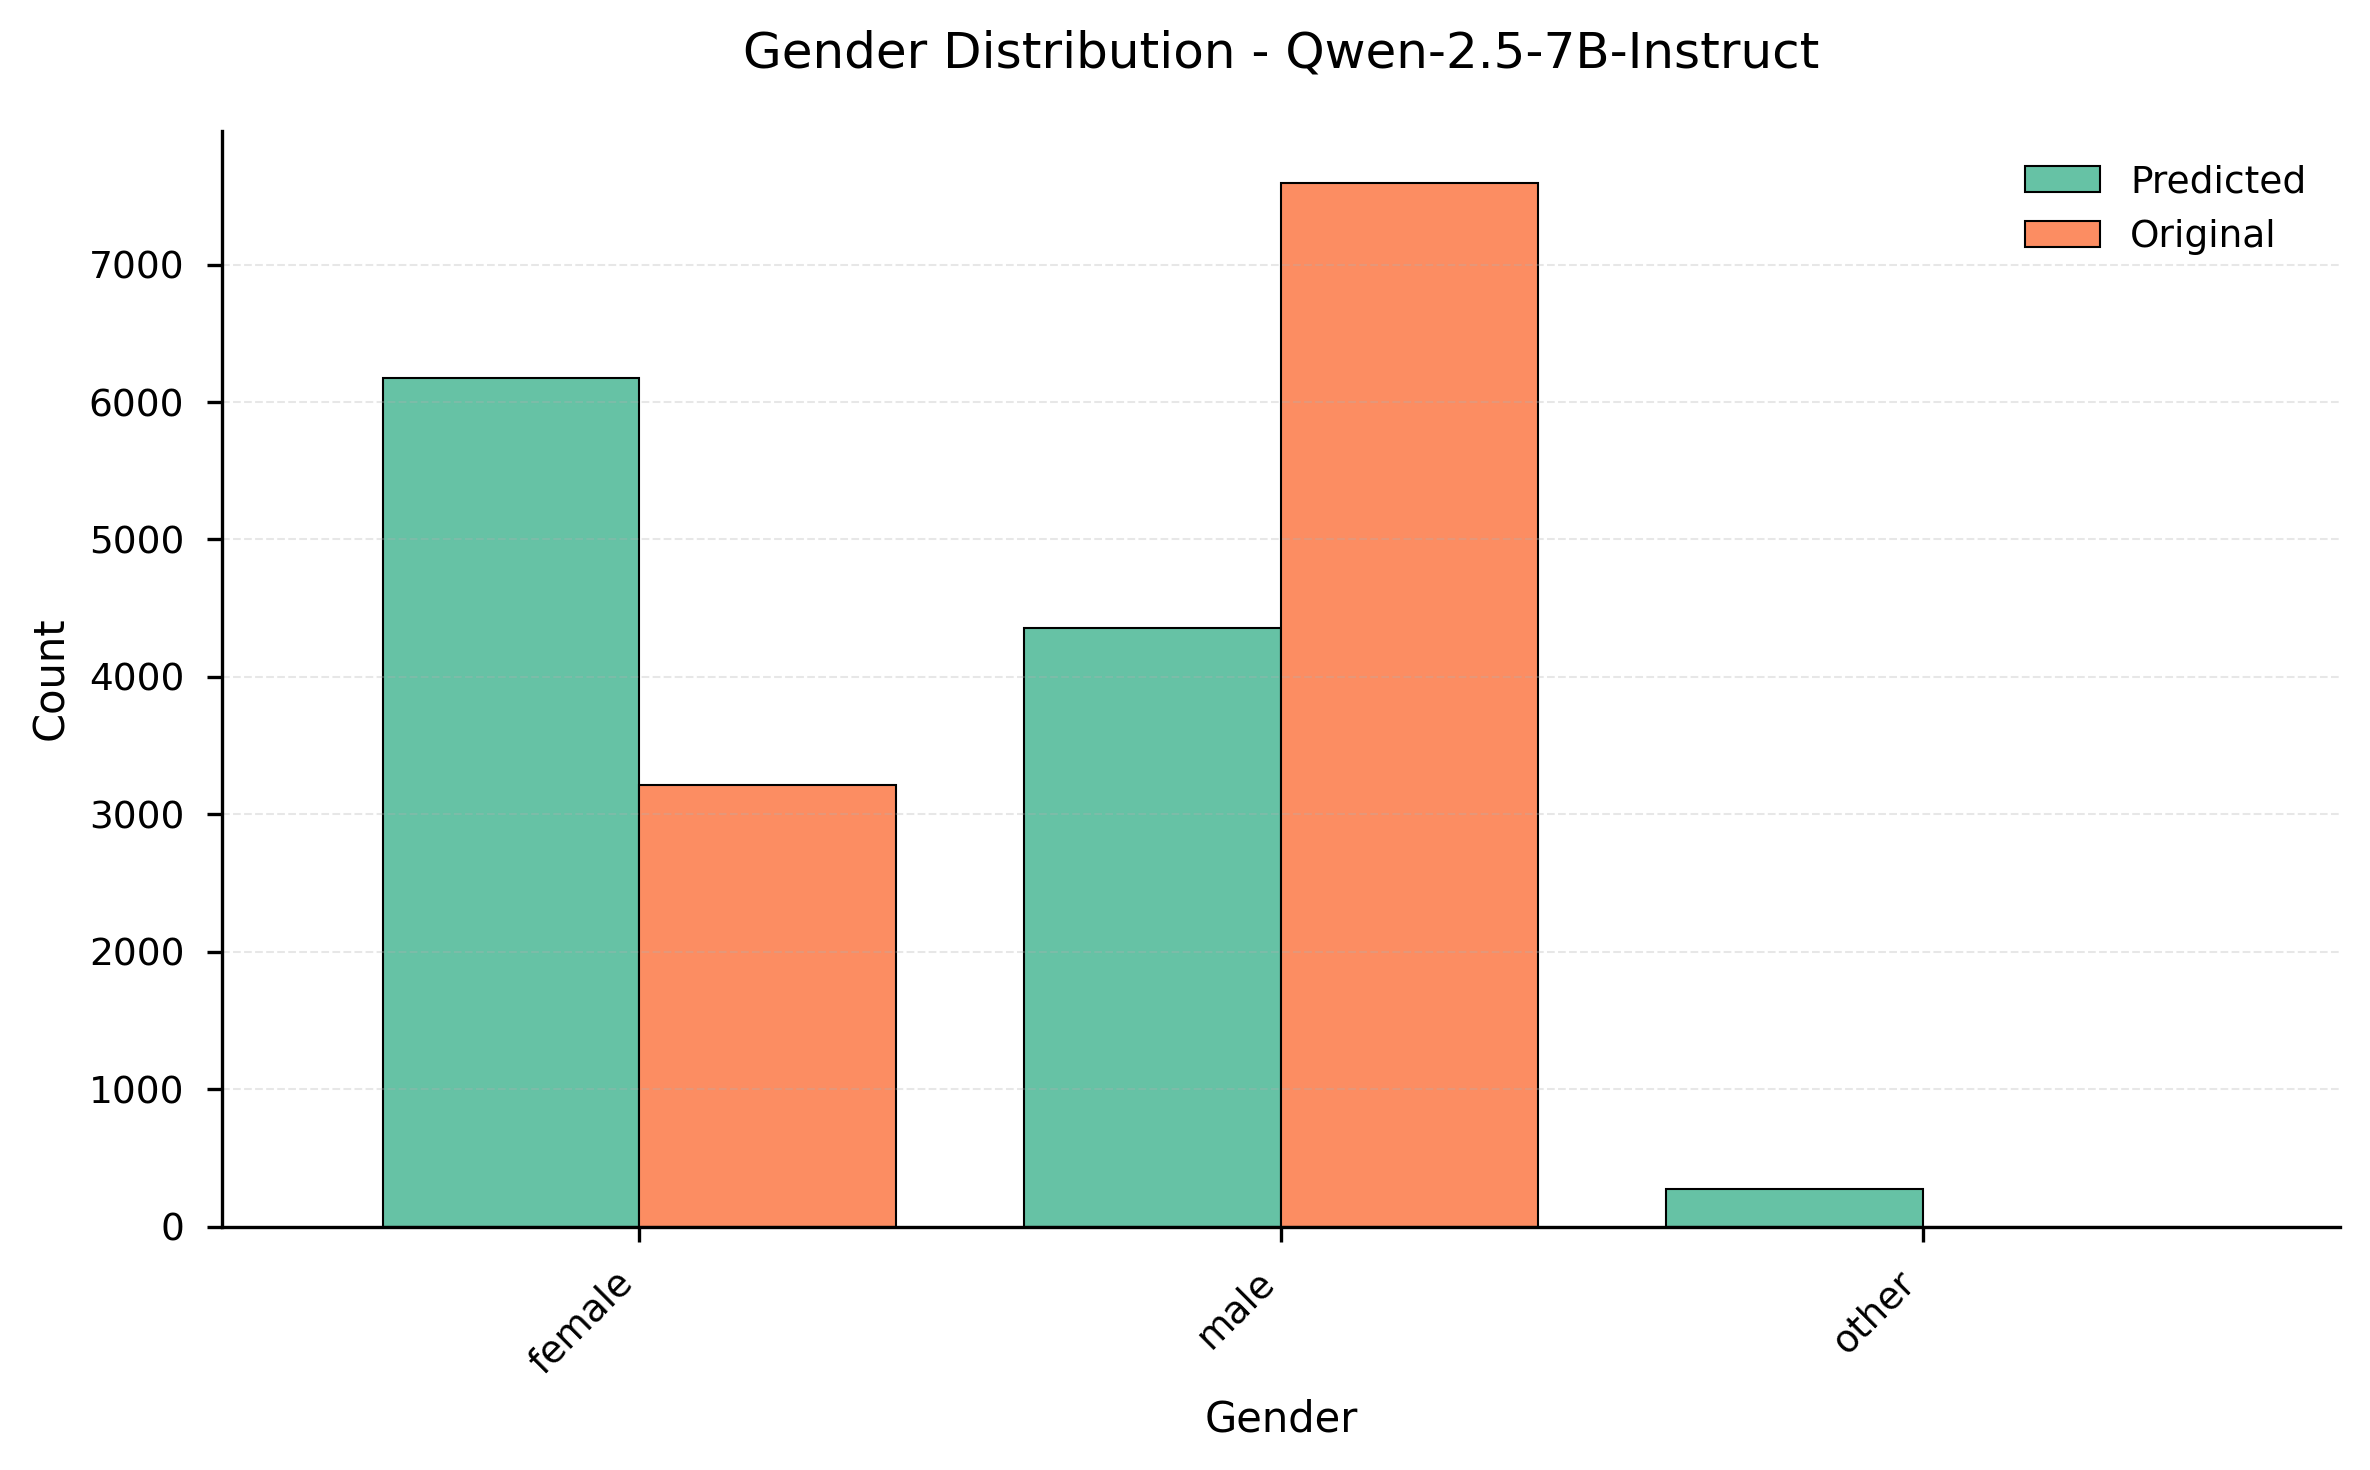

In [6]:
plot_continent_comparison(df_qwen, "Qwen-2.5-7B-Instruct")
plot_gender_comparison(df_qwen, "Qwen-2.5-7B-Instruct")

continent accuracy 	52.4334% 



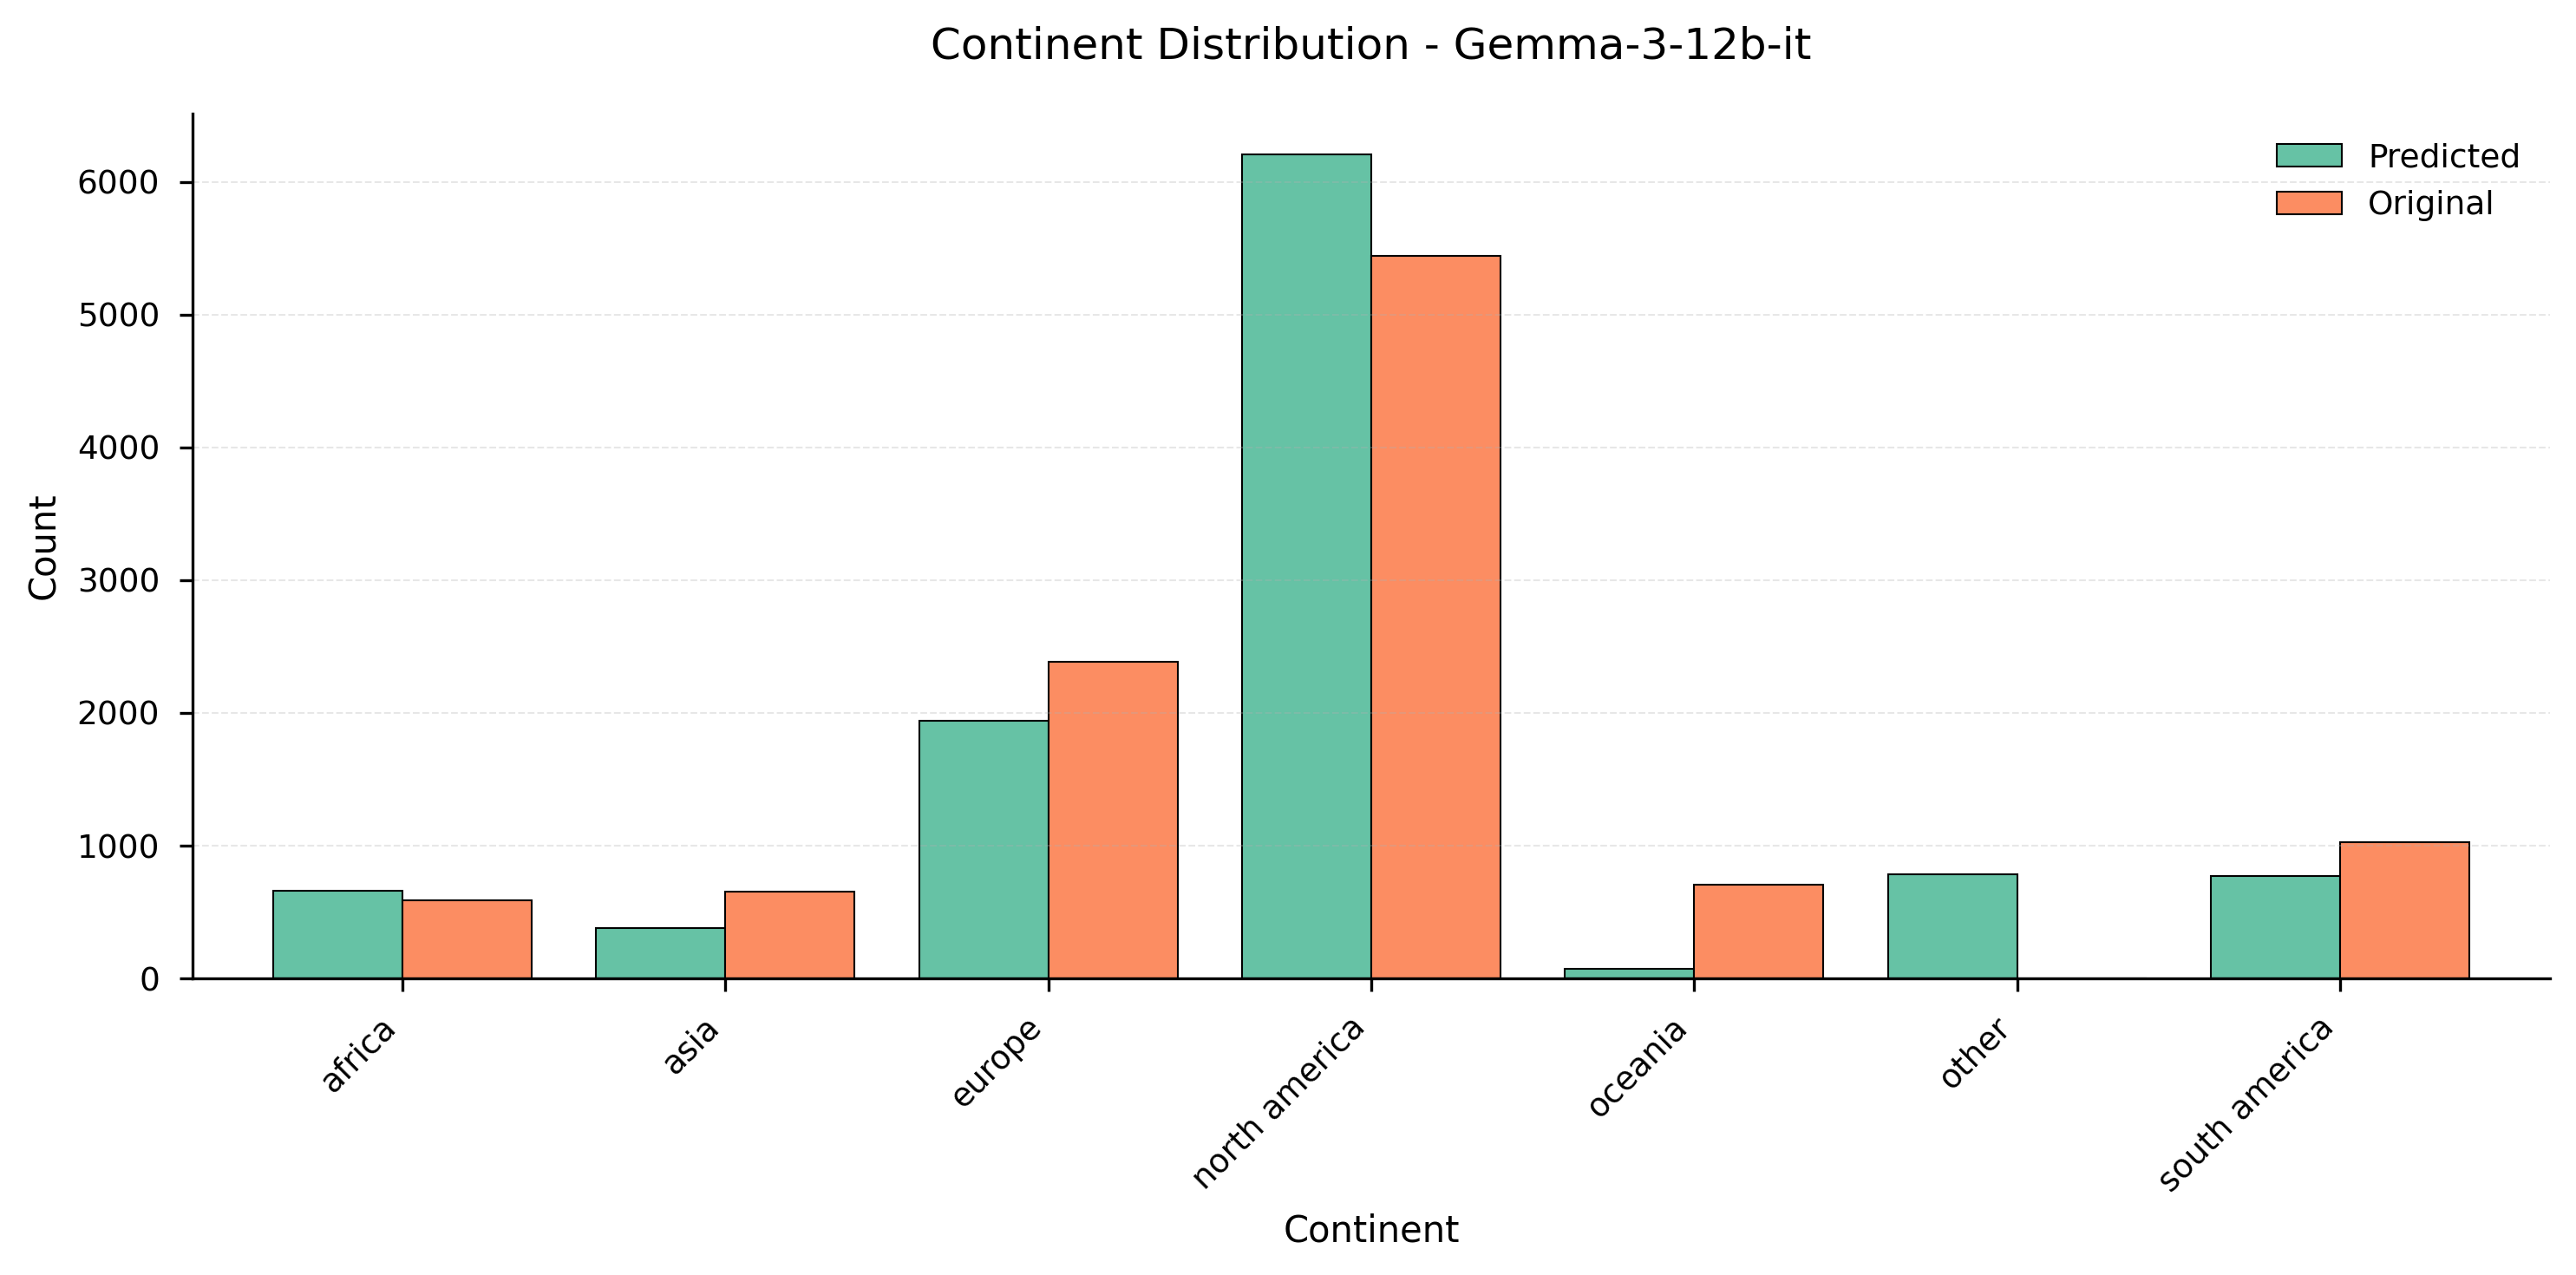

gender accuracy 	66.2380% 



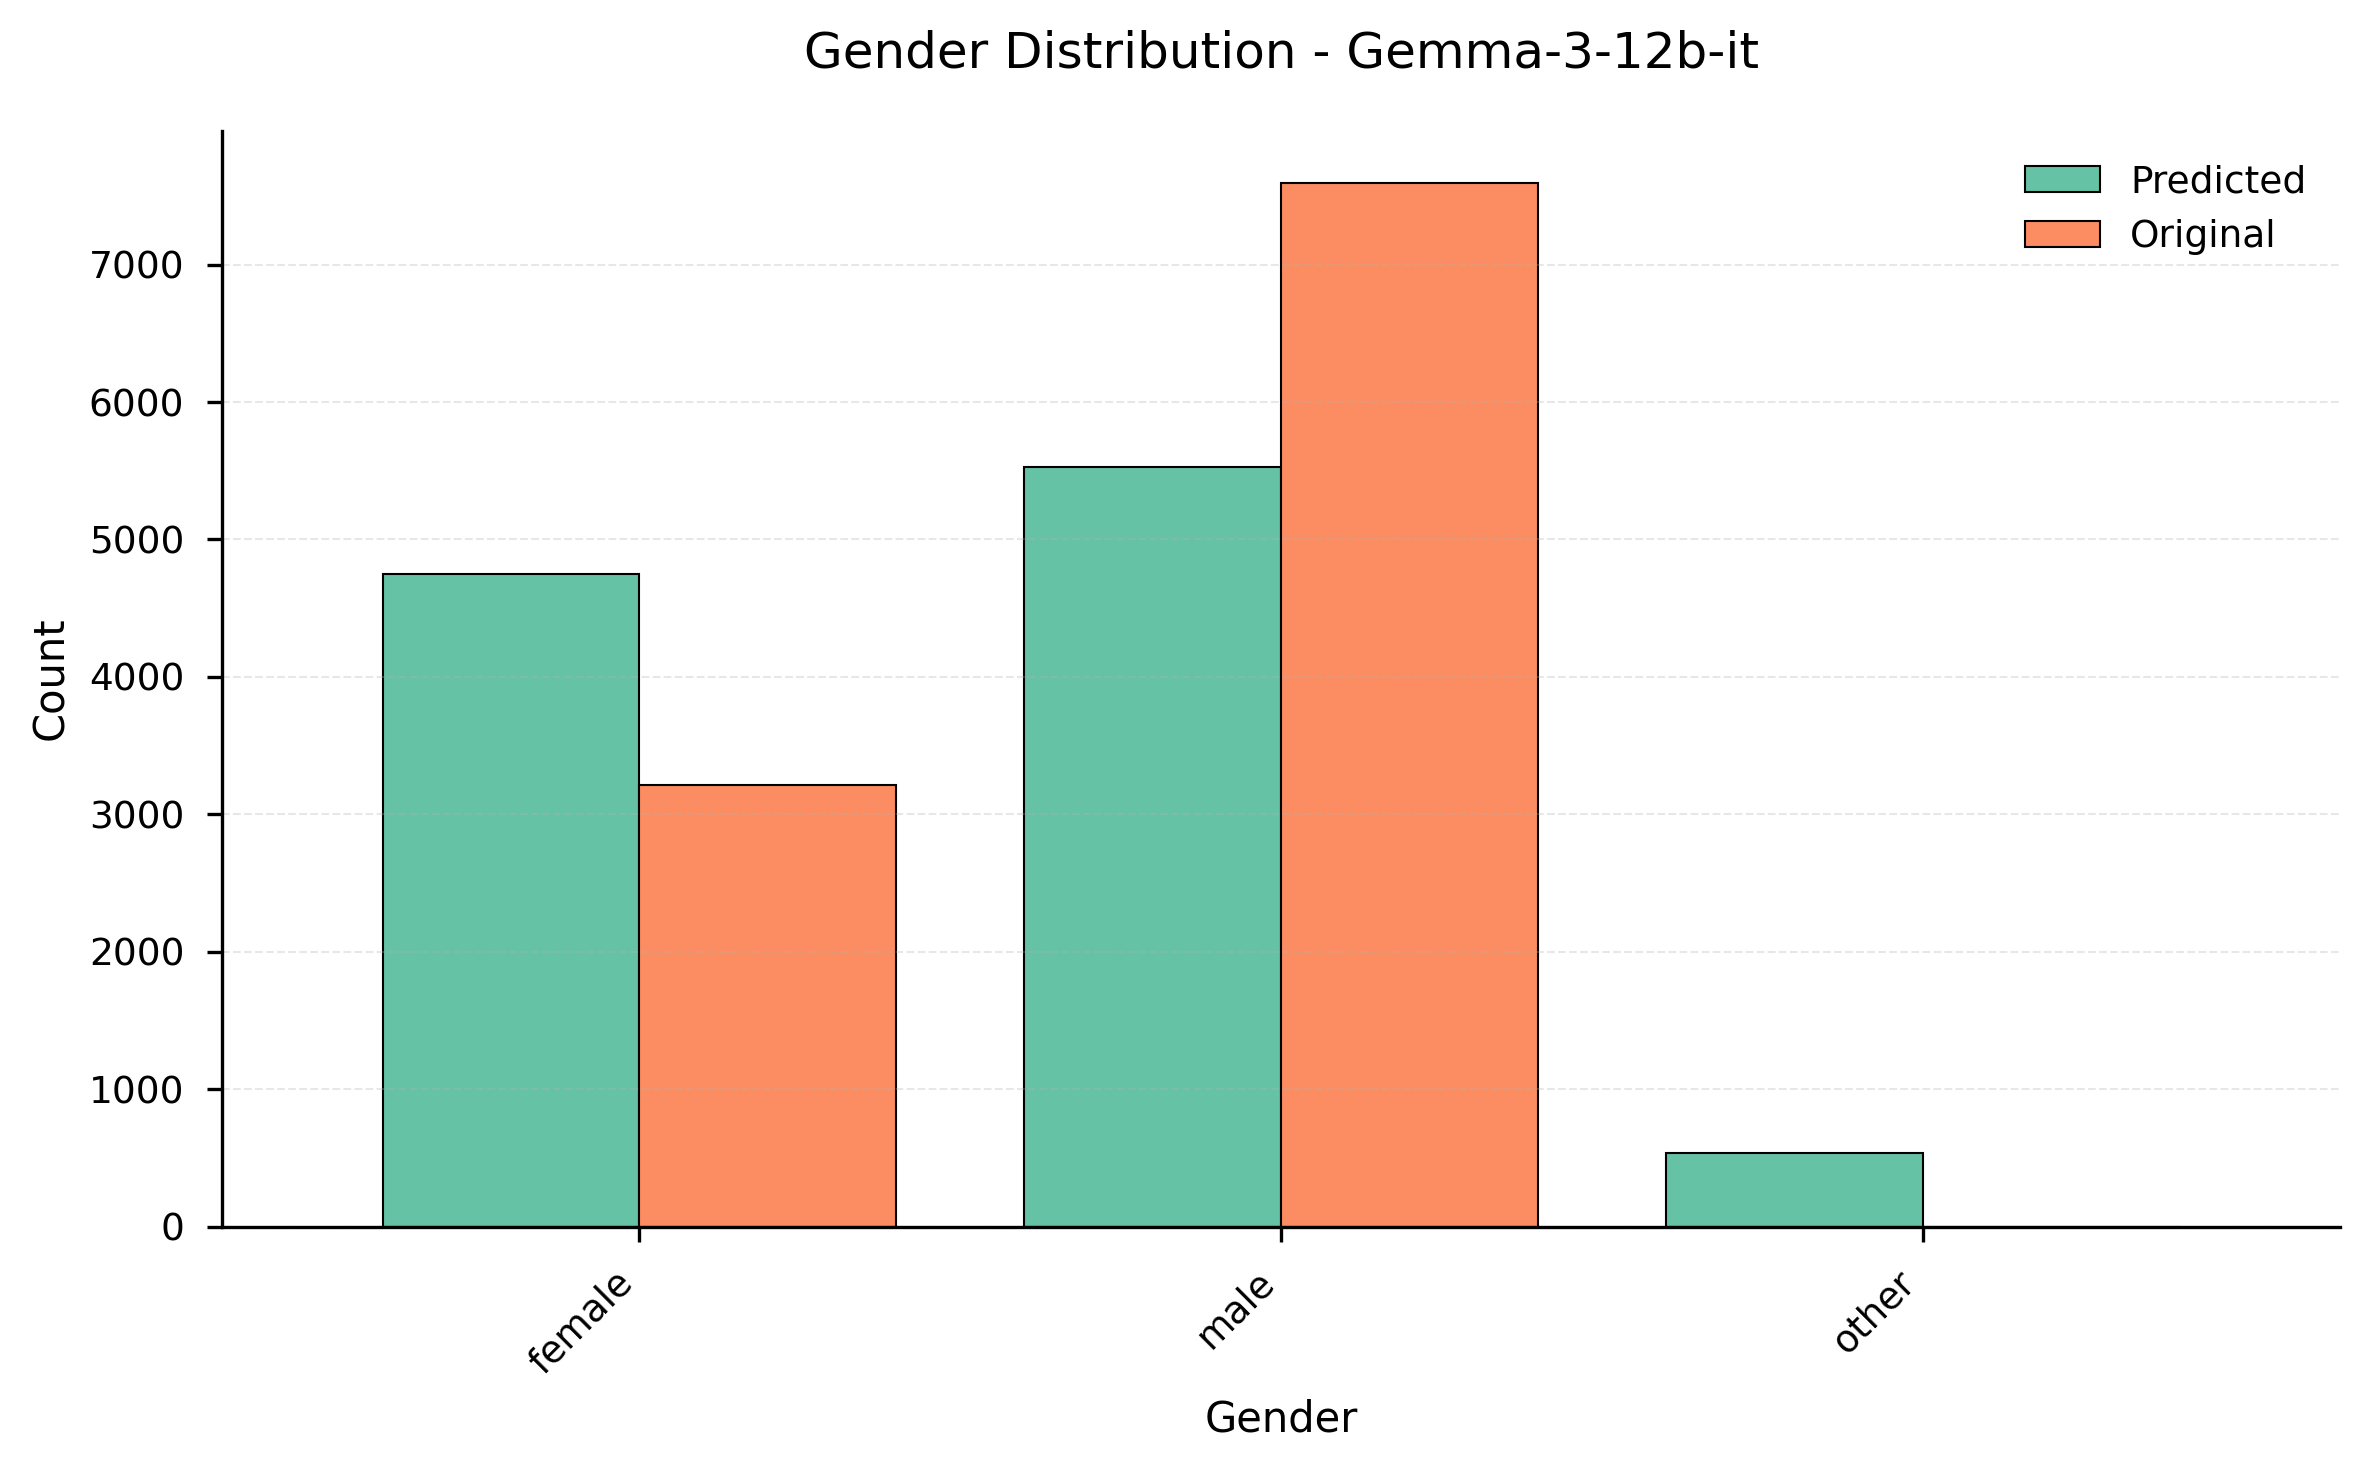

In [7]:
plot_continent_comparison(df_gemma, "Gemma-3-12b-it")
plot_gender_comparison(df_gemma, "Gemma-3-12b-it")

In [9]:
df_ministral_0 = pd.read_csv("Ministral-8B-Instruct-2410/Ministral-8B-Instruct-2410_gender_classification_rank_0.csv")
df_ministral_1 = pd.read_csv("Ministral-8B-Instruct-2410/Ministral-8B-Instruct-2410_gender_classification_rank_1.csv")
df_ministral_2 = pd.read_csv("Ministral-8B-Instruct-2410/Ministral-8B-Instruct-2410_gender_classification_rank_2.csv")
df_ministral_3 = pd.read_csv("Ministral-8B-Instruct-2410/Ministral-8B-Instruct-2410_gender_classification_rank_3.csv")
df_ministral_4 = pd.read_csv("Ministral-8B-Instruct-2410/Ministral-8B-Instruct-2410_gender_classification_rank_4.csv")
df_ministral_5 = pd.read_csv("Ministral-8B-Instruct-2410/Ministral-8B-Instruct-2410_gender_classification_rank_5.csv")
df_ministral_6 = pd.read_csv("Ministral-8B-Instruct-2410/Ministral-8B-Instruct-2410_gender_classification_rank_6.csv")
df_ministral_7 = pd.read_csv("Ministral-8B-Instruct-2410/Ministral-8B-Instruct-2410_gender_classification_rank_7.csv")

df_minstral = pd.concat([df_ministral_0, df_ministral_1, df_ministral_2, df_ministral_3,
                         df_ministral_4, df_ministral_5, df_ministral_6, df_ministral_7], ignore_index=True)

len(df_minstral)

10808

In [10]:
df_minstral['original_continent'] = df_minstral['original_continent'].replace('Latin America', 'South America')
df_minstral.original_continent.value_counts()

original_continent
North America    5444
Europe           2387
South America    1024
Oceania           706
Asia              657
Africa            590
Name: count, dtype: int64

continent accuracy 	45.8827% 



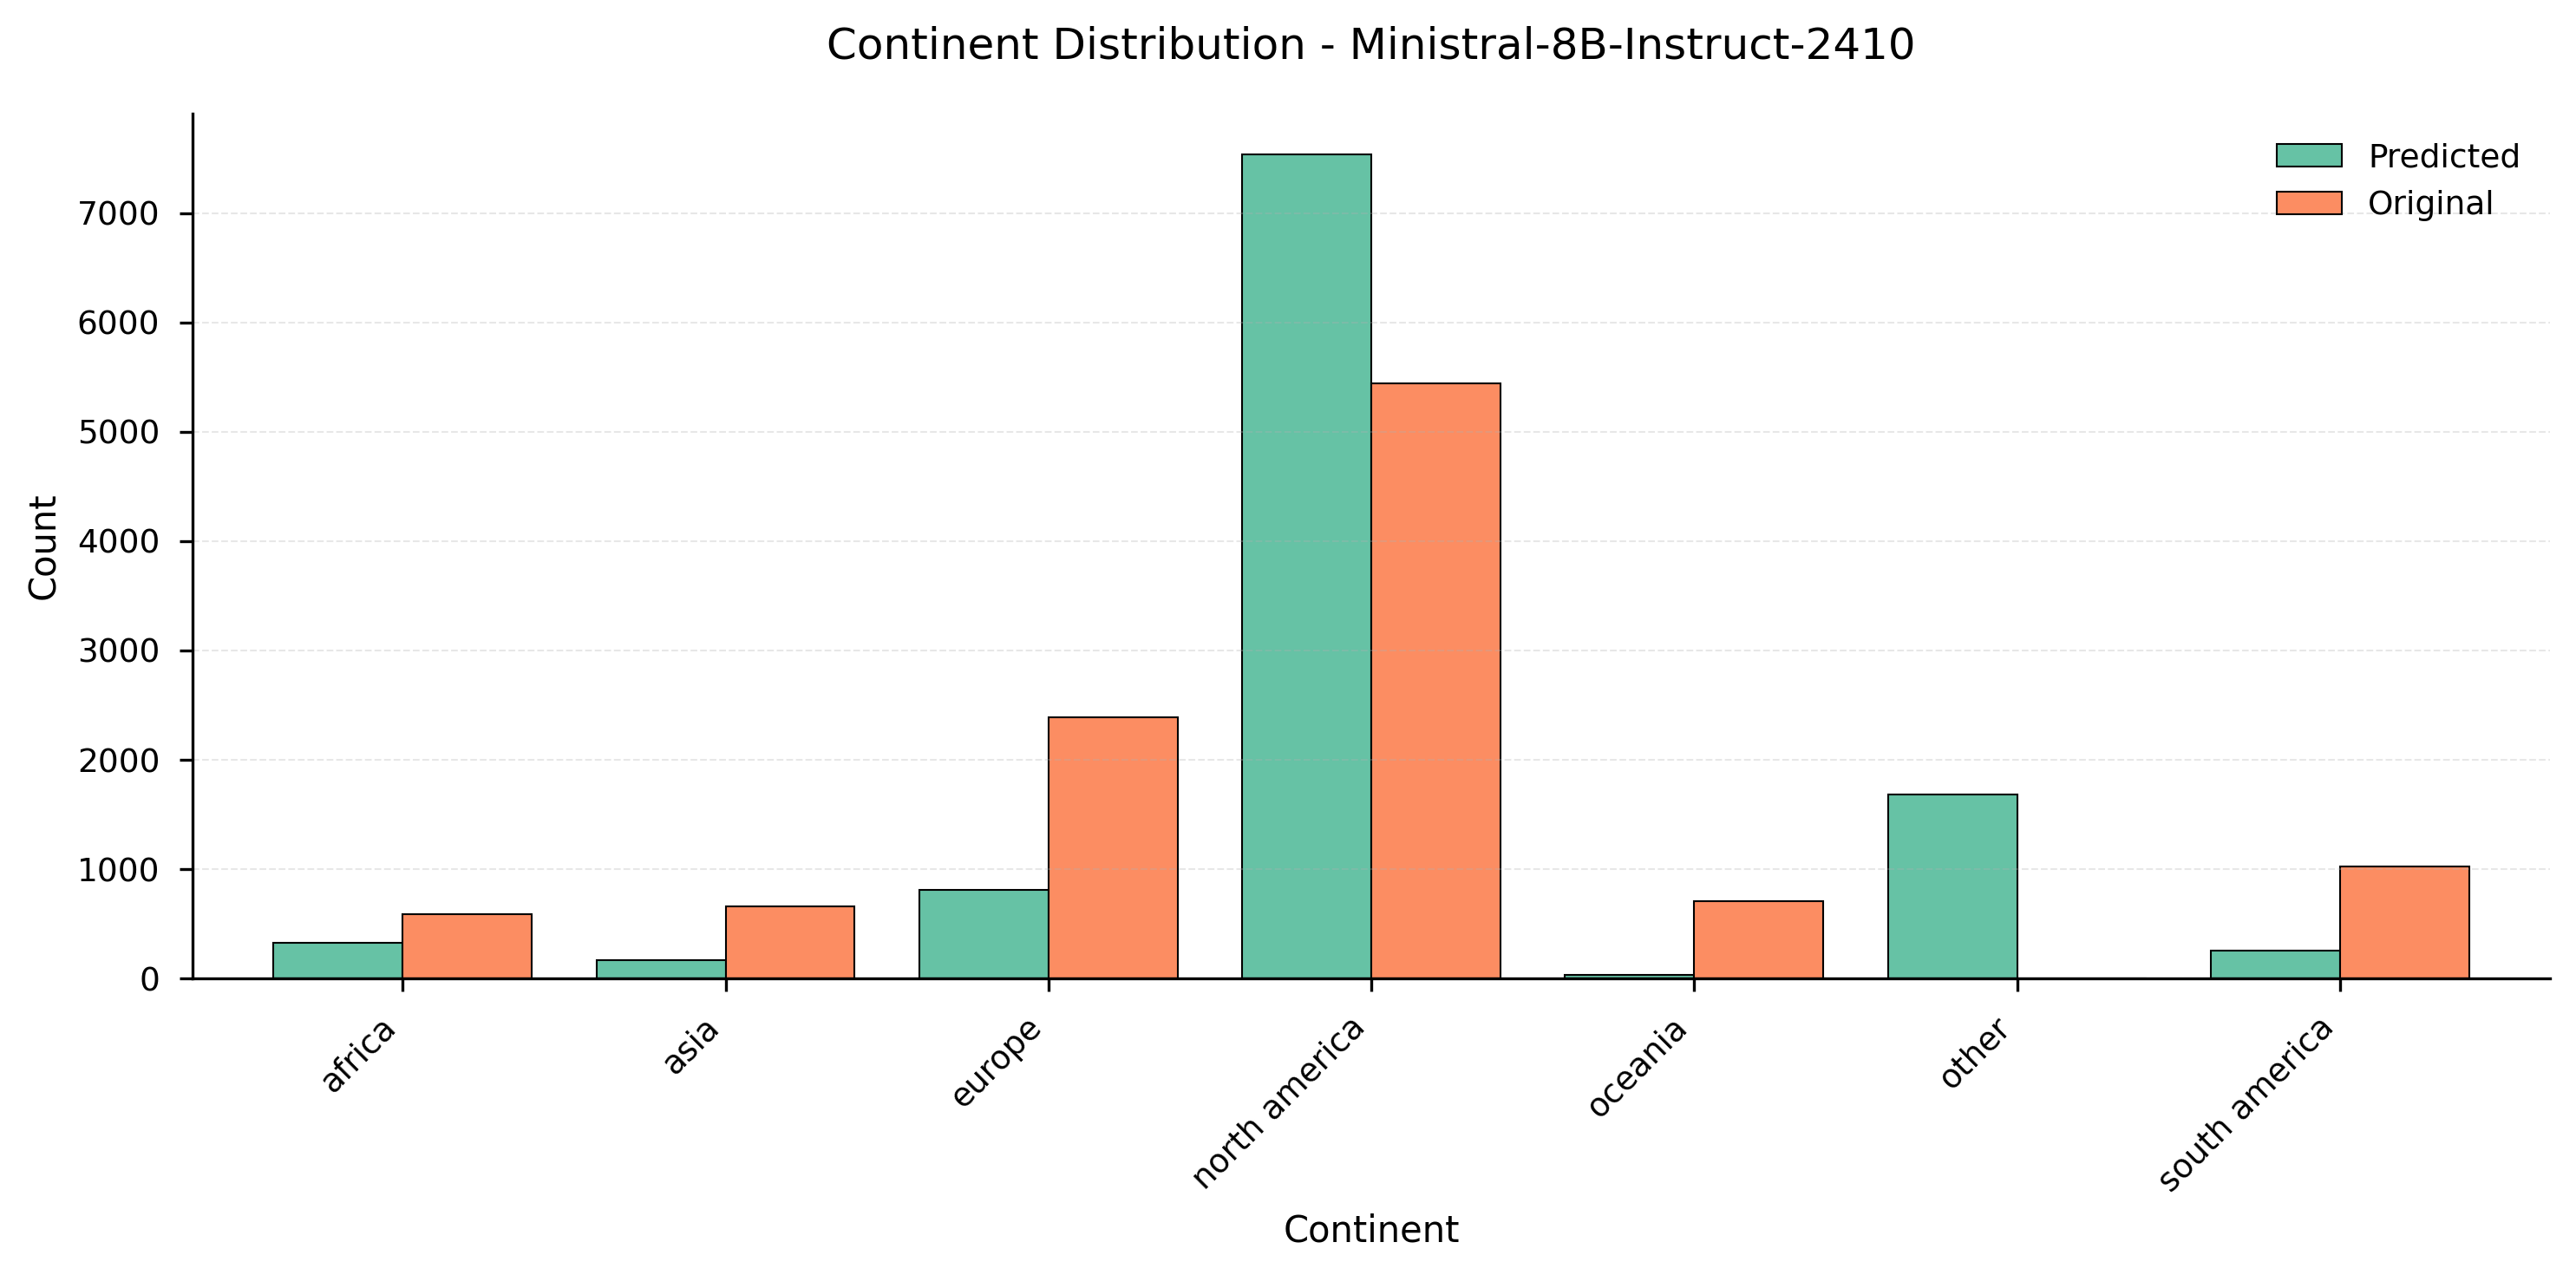

gender accuracy 	47.3353% 



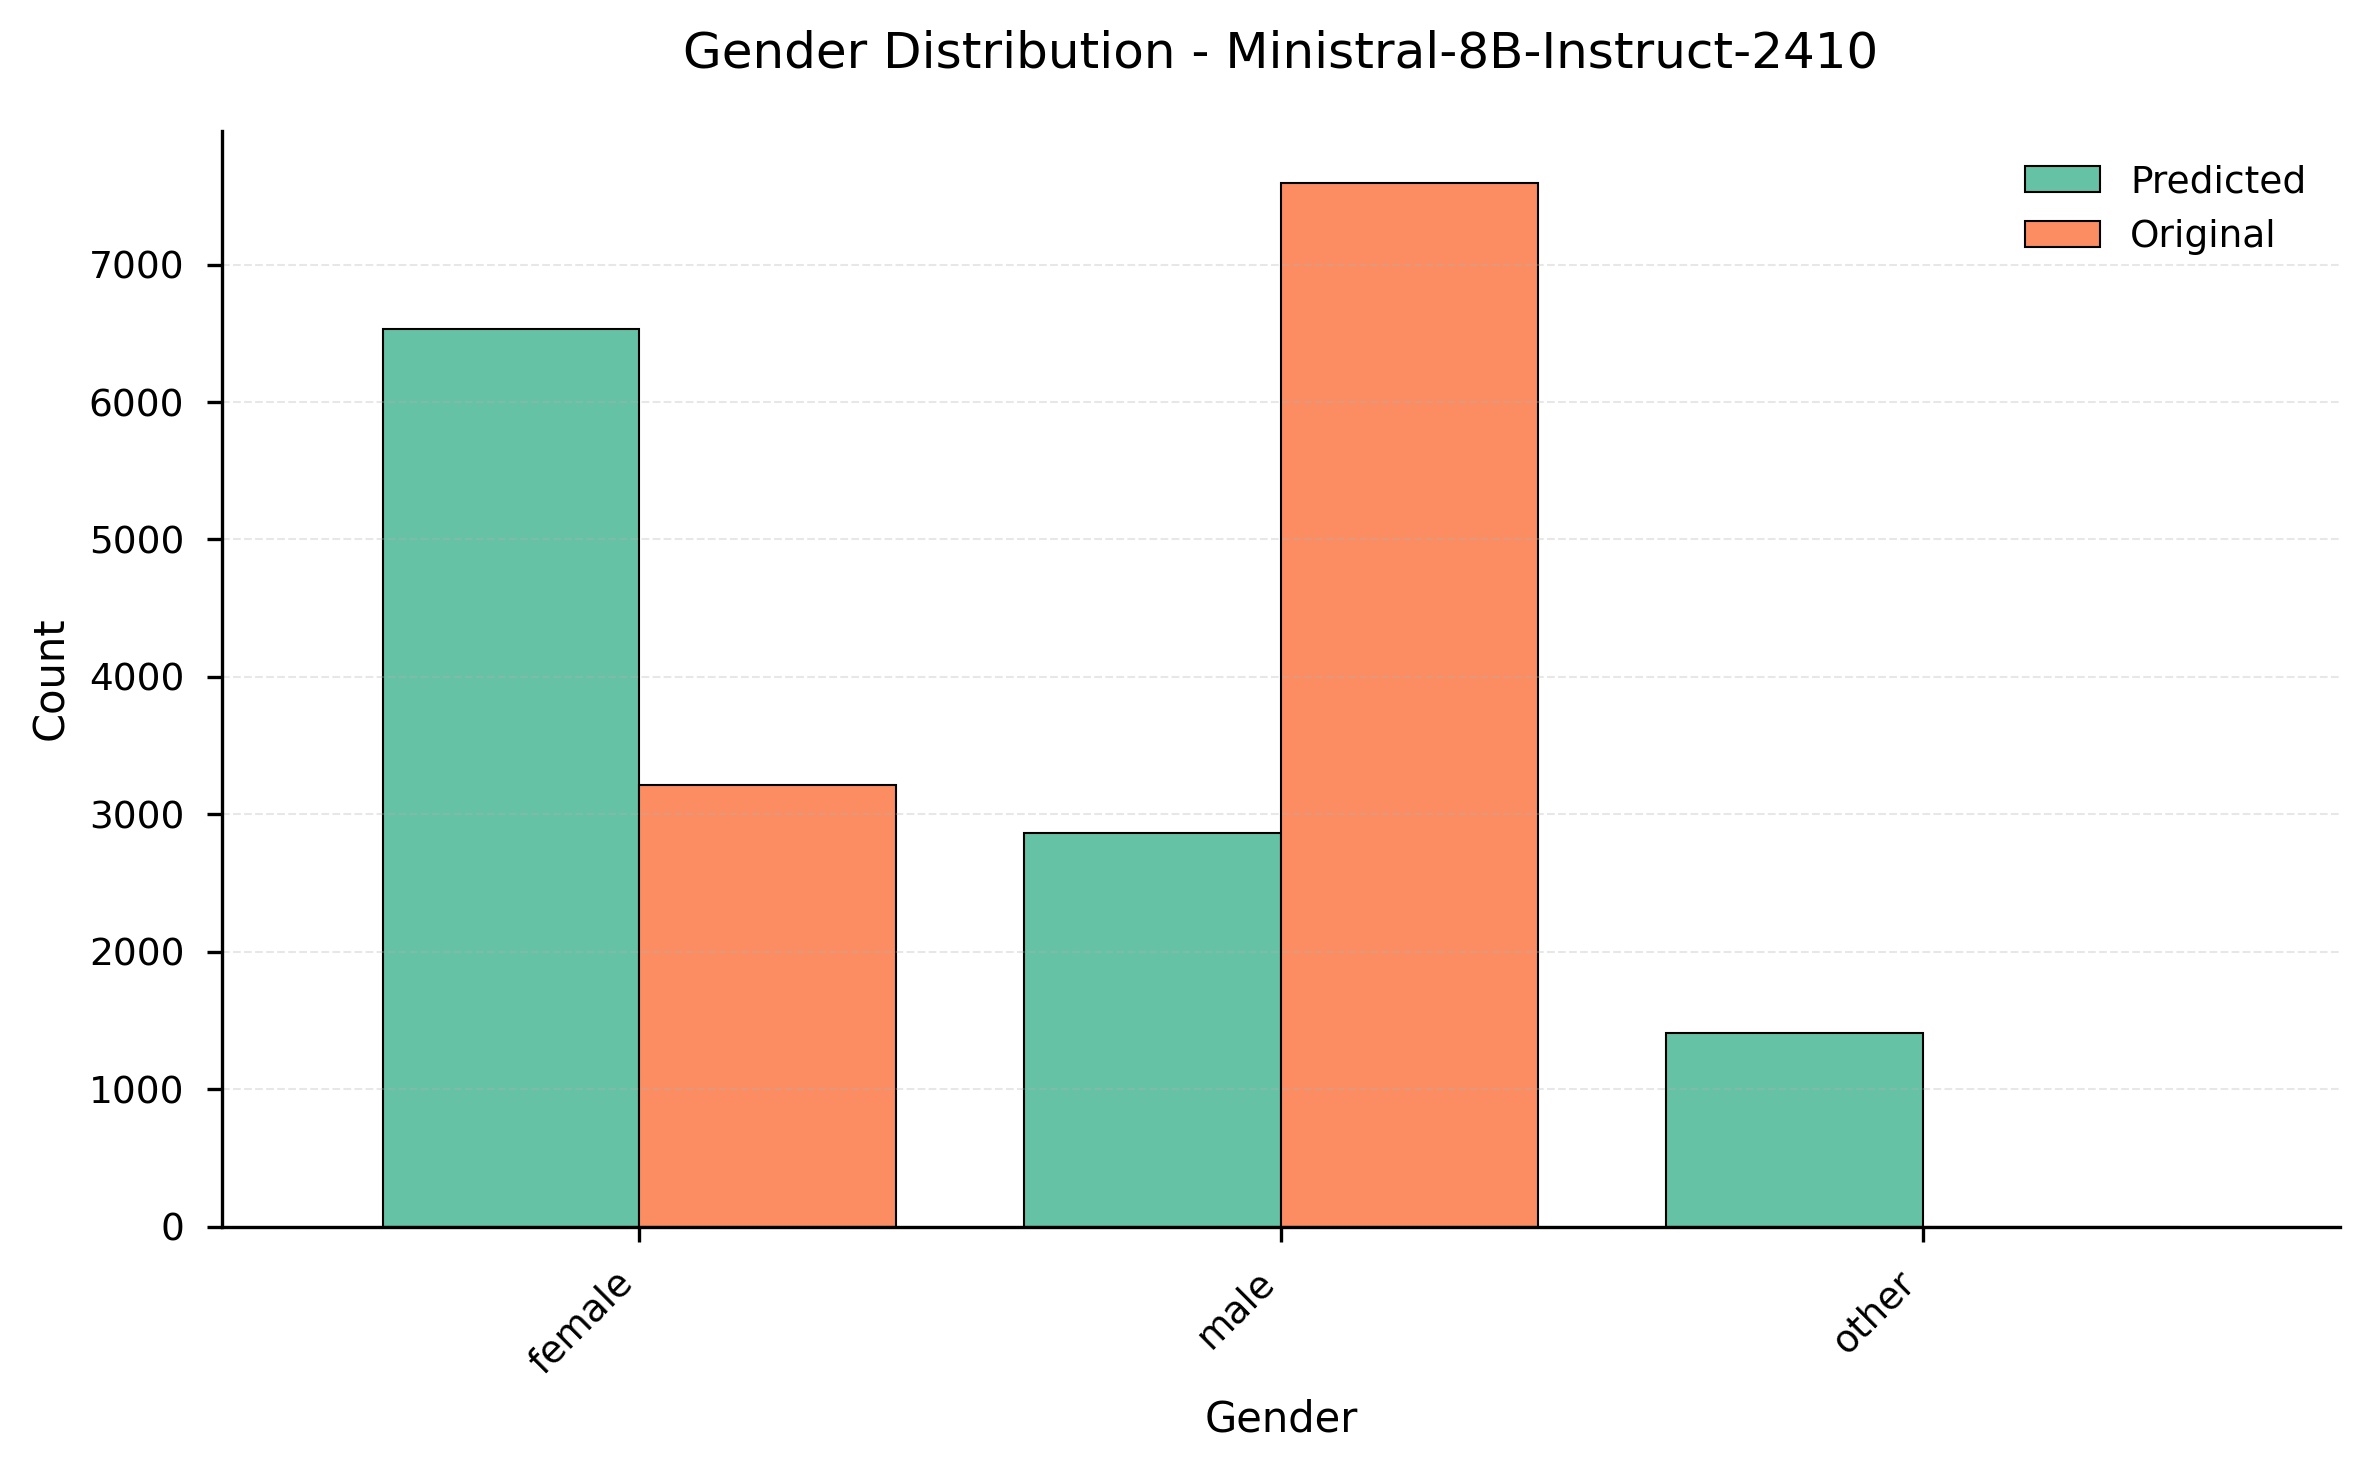

In [11]:
plot_continent_comparison(df_minstral, "Ministral-8B-Instruct-2410")
plot_gender_comparison(df_minstral, "Ministral-8B-Instruct-2410")

In [12]:
df_deepseek1_5_0 = pd.read_csv("DeepSeek-R1-Distill-Qwen-1.5B/DeepSeek-R1-Distill-Qwen-1.5B_gender_classification_rank_0.csv")
df_deepseek1_5_1 = pd.read_csv("DeepSeek-R1-Distill-Qwen-1.5B/DeepSeek-R1-Distill-Qwen-1.5B_gender_classification_rank_1.csv")
df_deepseek1_5_2 = pd.read_csv("DeepSeek-R1-Distill-Qwen-1.5B/DeepSeek-R1-Distill-Qwen-1.5B_gender_classification_rank_2.csv")
df_deepseek1_5_3 = pd.read_csv("DeepSeek-R1-Distill-Qwen-1.5B/DeepSeek-R1-Distill-Qwen-1.5B_gender_classification_rank_3.csv")

df_deepseek1_5 = pd.concat([df_deepseek1_5_0, df_deepseek1_5_1, df_deepseek1_5_2, df_deepseek1_5_3], ignore_index=True)
len(df_deepseek1_5)

10808

In [13]:
df_deepseek1_5['original_continent'] = df_deepseek1_5['original_continent'].replace('Latin America', 'South America')
df_deepseek1_5.original_continent.value_counts()

original_continent
North America    5444
Europe           2387
South America    1024
Oceania           706
Asia              657
Africa            590
Name: count, dtype: int64

continent accuracy 	11.4175% 



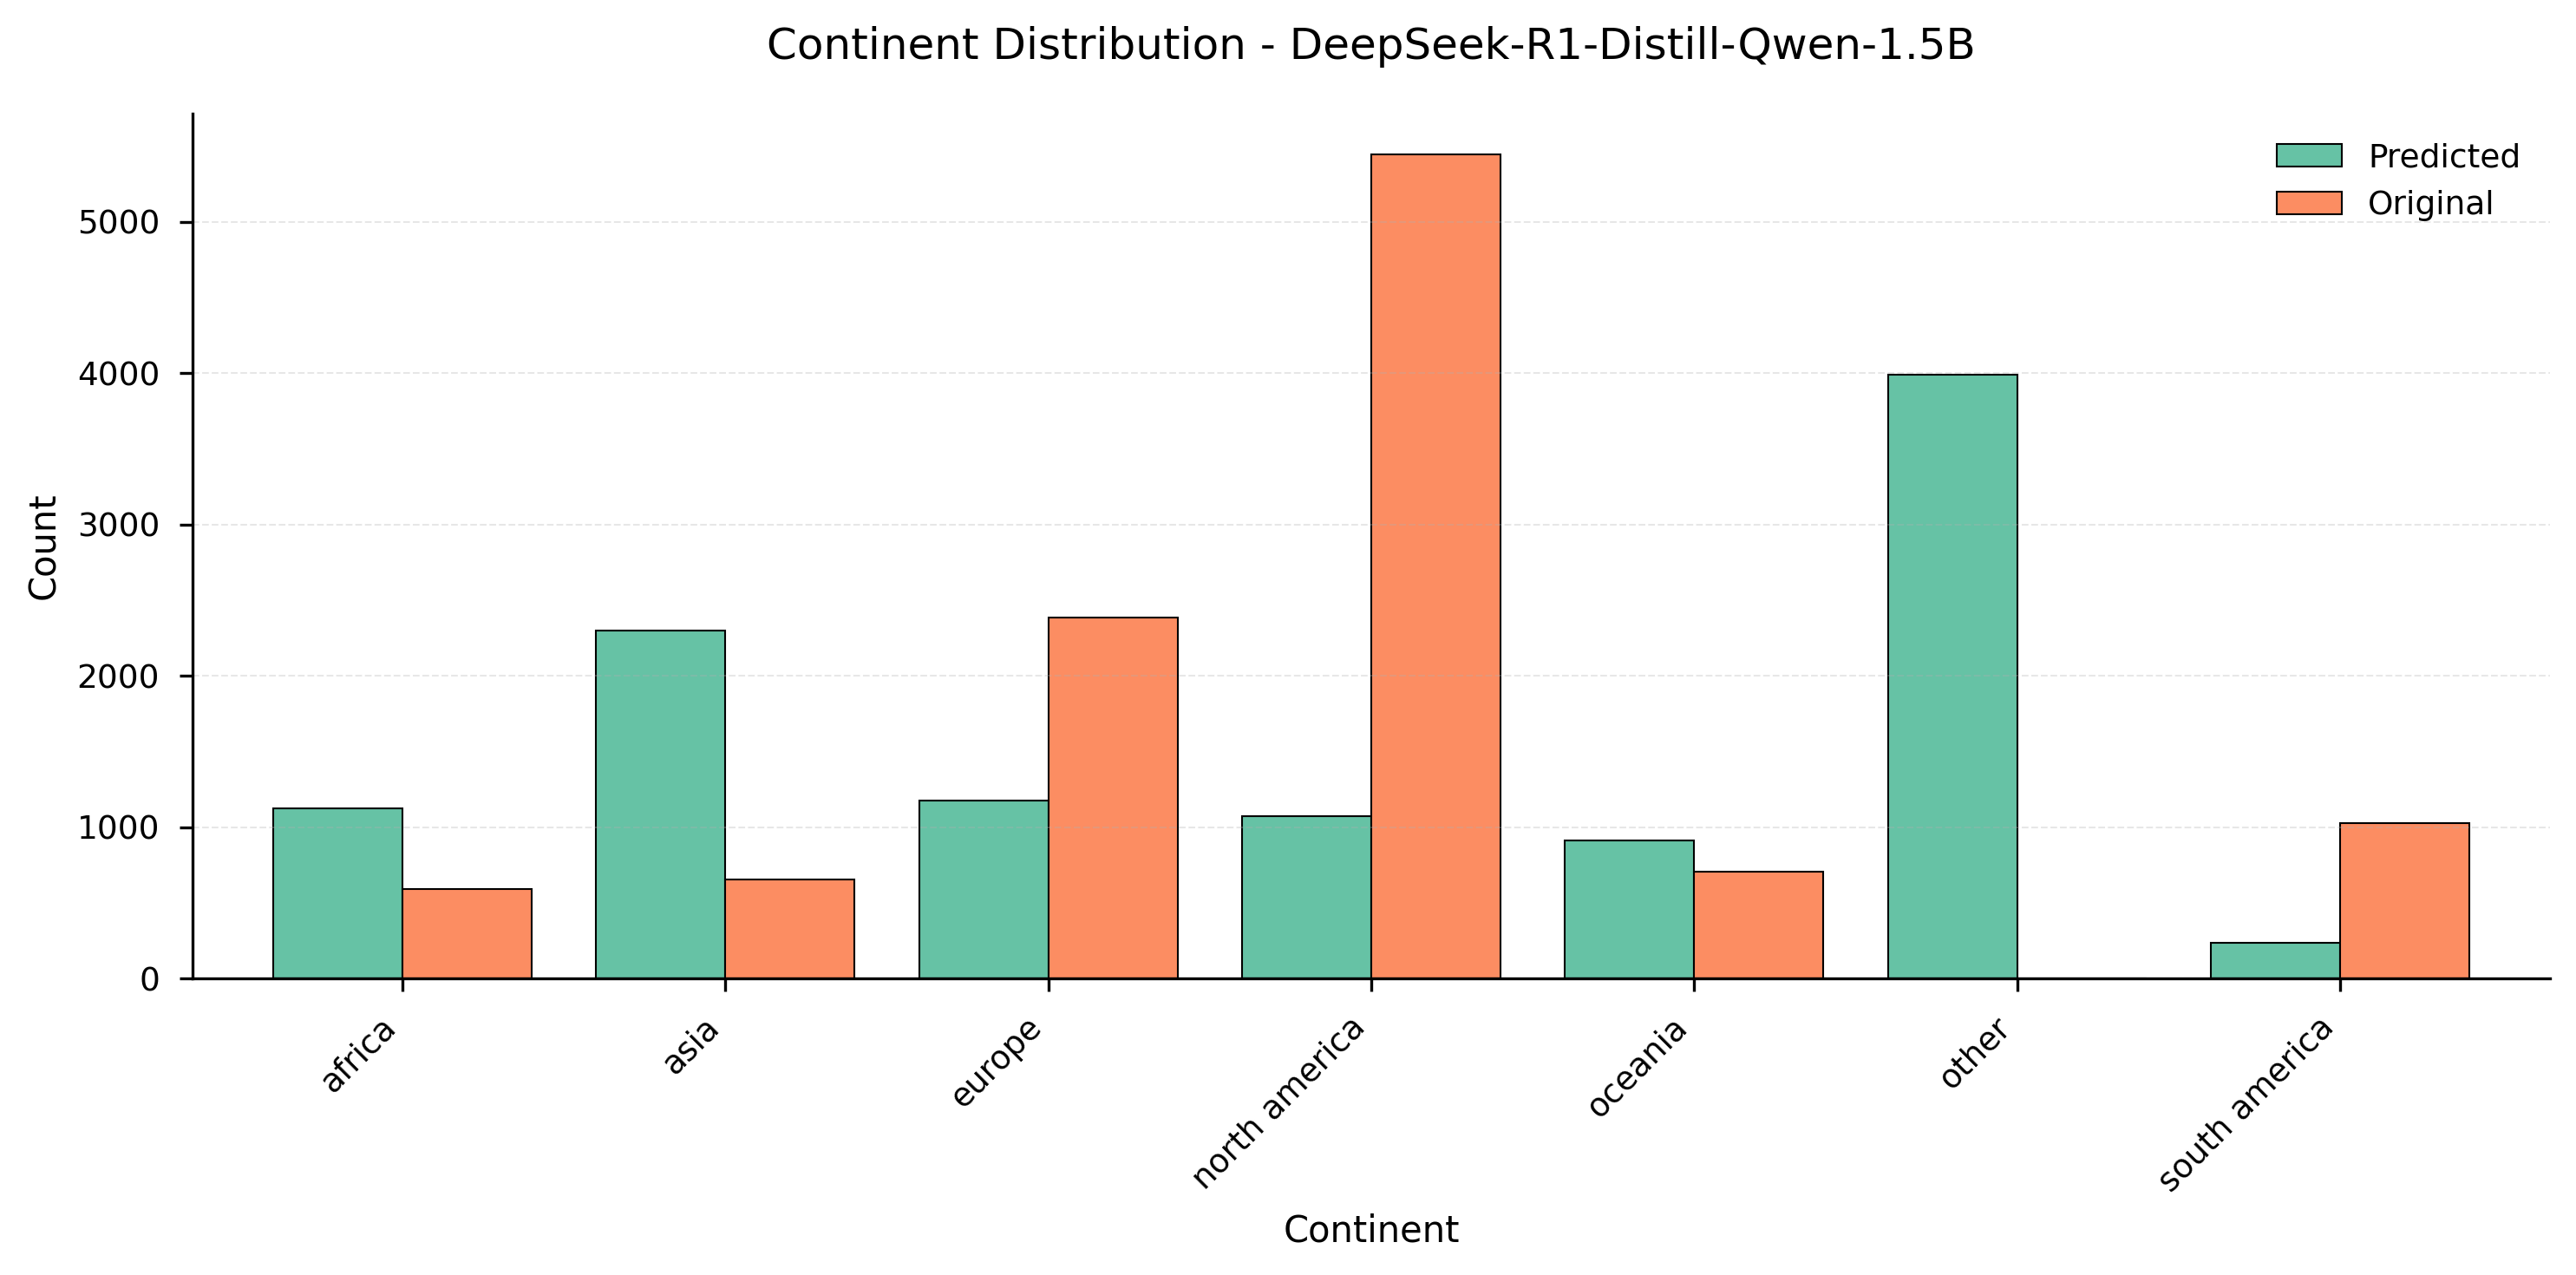

gender accuracy 	34.3819% 



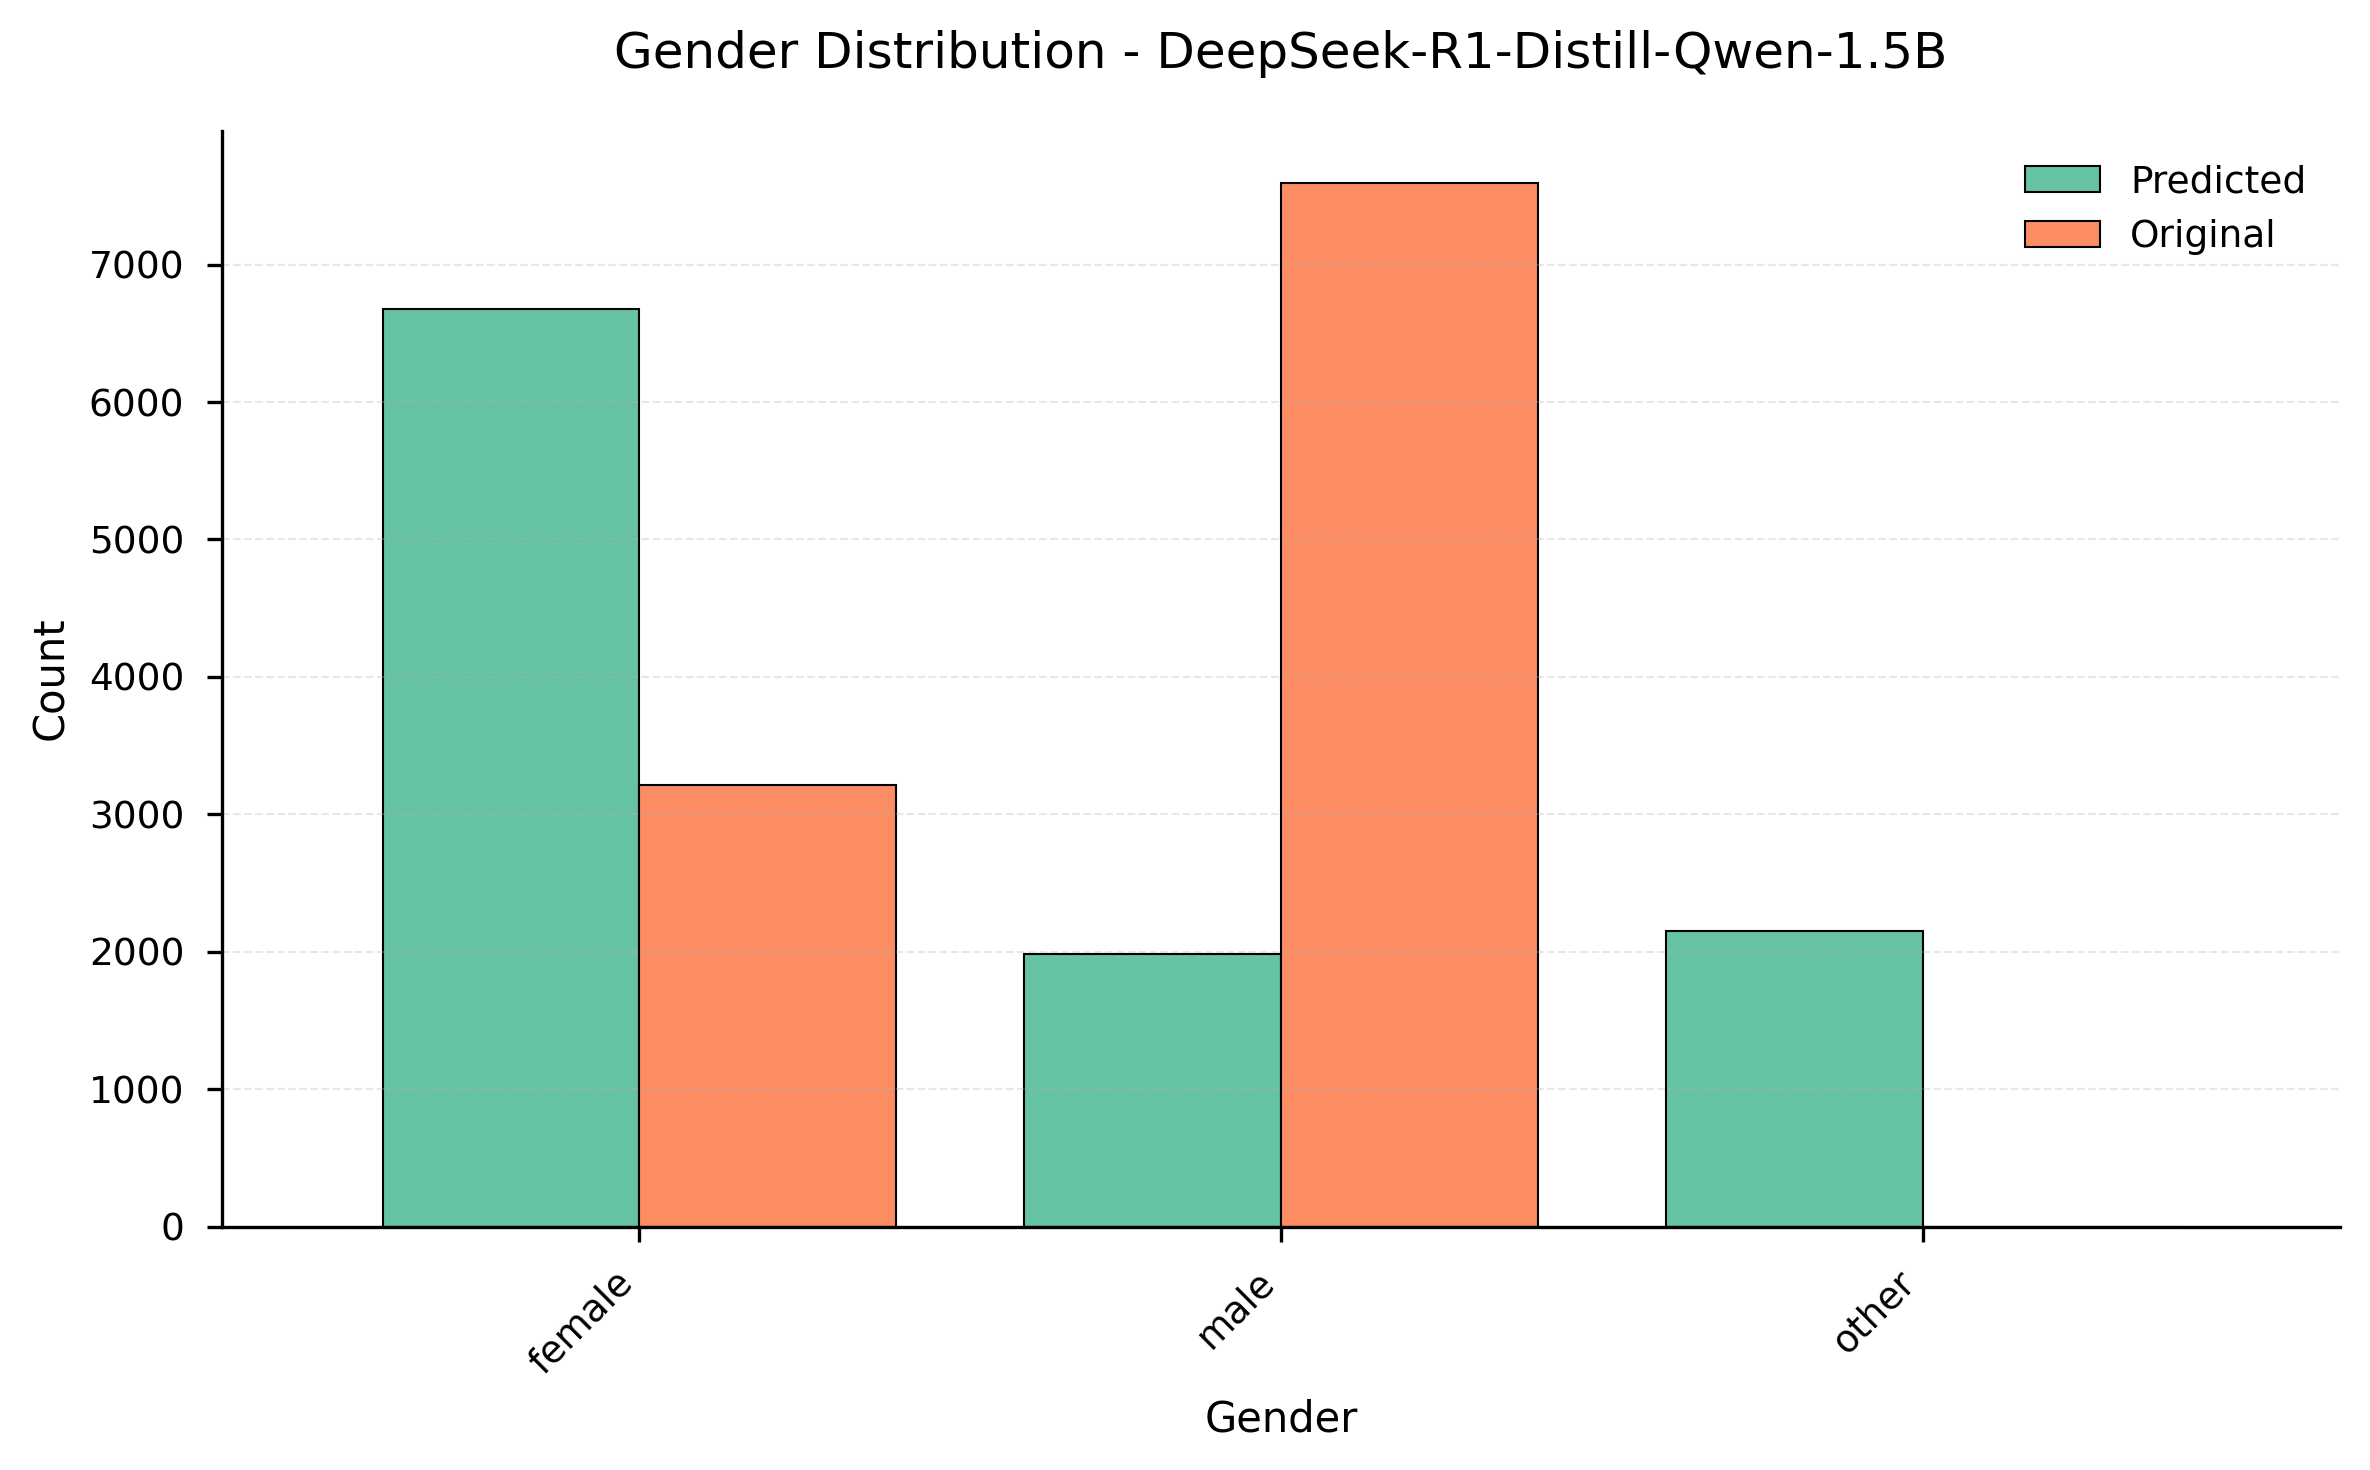

In [14]:
plot_continent_comparison(df_deepseek1_5, "DeepSeek-R1-Distill-Qwen-1.5B")
plot_gender_comparison(df_deepseek1_5, "DeepSeek-R1-Distill-Qwen-1.5B")

In [16]:
df_minstral.to_csv("Ministral-8B-Instruct-2410/Ministral-8B-Instruct-2410_gender_classification_merged.csv", index=False)
df_deepseek1_5.to_csv("DeepSeek-R1-Distill-Qwen-1.5B/DeepSeek-R1-Distill-Qwen-1.5B_gender_classification_merged.csv", index=False)

In [4]:
df_deepseek1_5_quantized_0 = pd.read_csv("DeepSeek-R1-Distill-Qwen-1.5B-bnb-4bit/DeepSeek-R1-Distill-Qwen-1.5B-bnb-4bit_gender_classification_rank_0.csv")
df_deepseek1_5_quantized_1 = pd.read_csv("DeepSeek-R1-Distill-Qwen-1.5B-bnb-4bit/DeepSeek-R1-Distill-Qwen-1.5B-bnb-4bit_gender_classification_rank_1.csv")
df_deepseek1_5_quantized_2 = pd.read_csv("DeepSeek-R1-Distill-Qwen-1.5B-bnb-4bit/DeepSeek-R1-Distill-Qwen-1.5B-bnb-4bit_gender_classification_rank_2.csv")
df_deepseek1_5_quantized_3 = pd.read_csv("DeepSeek-R1-Distill-Qwen-1.5B-bnb-4bit/DeepSeek-R1-Distill-Qwen-1.5B-bnb-4bit_gender_classification_rank_3.csv")
df_deepseek1_5_quantized_4 = pd.read_csv("DeepSeek-R1-Distill-Qwen-1.5B-bnb-4bit/DeepSeek-R1-Distill-Qwen-1.5B-bnb-4bit_gender_classification_rank_4.csv")
df_deepseek1_5_quantized_5 = pd.read_csv("DeepSeek-R1-Distill-Qwen-1.5B-bnb-4bit/DeepSeek-R1-Distill-Qwen-1.5B-bnb-4bit_gender_classification_rank_5.csv")
df_deepseek1_5_quantized_6 = pd.read_csv("DeepSeek-R1-Distill-Qwen-1.5B-bnb-4bit/DeepSeek-R1-Distill-Qwen-1.5B-bnb-4bit_gender_classification_rank_6.csv")
df_deepseek1_5_quantized_7 = pd.read_csv("DeepSeek-R1-Distill-Qwen-1.5B-bnb-4bit/DeepSeek-R1-Distill-Qwen-1.5B-bnb-4bit_gender_classification_rank_7.csv")

df_deepseek1_5_quantized = pd.concat([df_deepseek1_5_quantized_0, df_deepseek1_5_quantized_1, df_deepseek1_5_quantized_2, df_deepseek1_5_quantized_3,
                                      df_deepseek1_5_quantized_4, df_deepseek1_5_quantized_5, df_deepseek1_5_quantized_6, df_deepseek1_5_quantized_7], ignore_index=True)

df_deepseek1_5_quantized['original_continent'] = df_deepseek1_5_quantized['original_continent'].replace('Latin America', 'South America')
df_deepseek1_5_quantized.original_continent.value_counts()

original_continent
North America    5444
Europe           2387
South America    1024
Oceania           706
Asia              657
Africa            590
Name: count, dtype: int64

In [5]:
len(df_deepseek1_5_quantized)

10808

continent accuracy 	10.4182% 



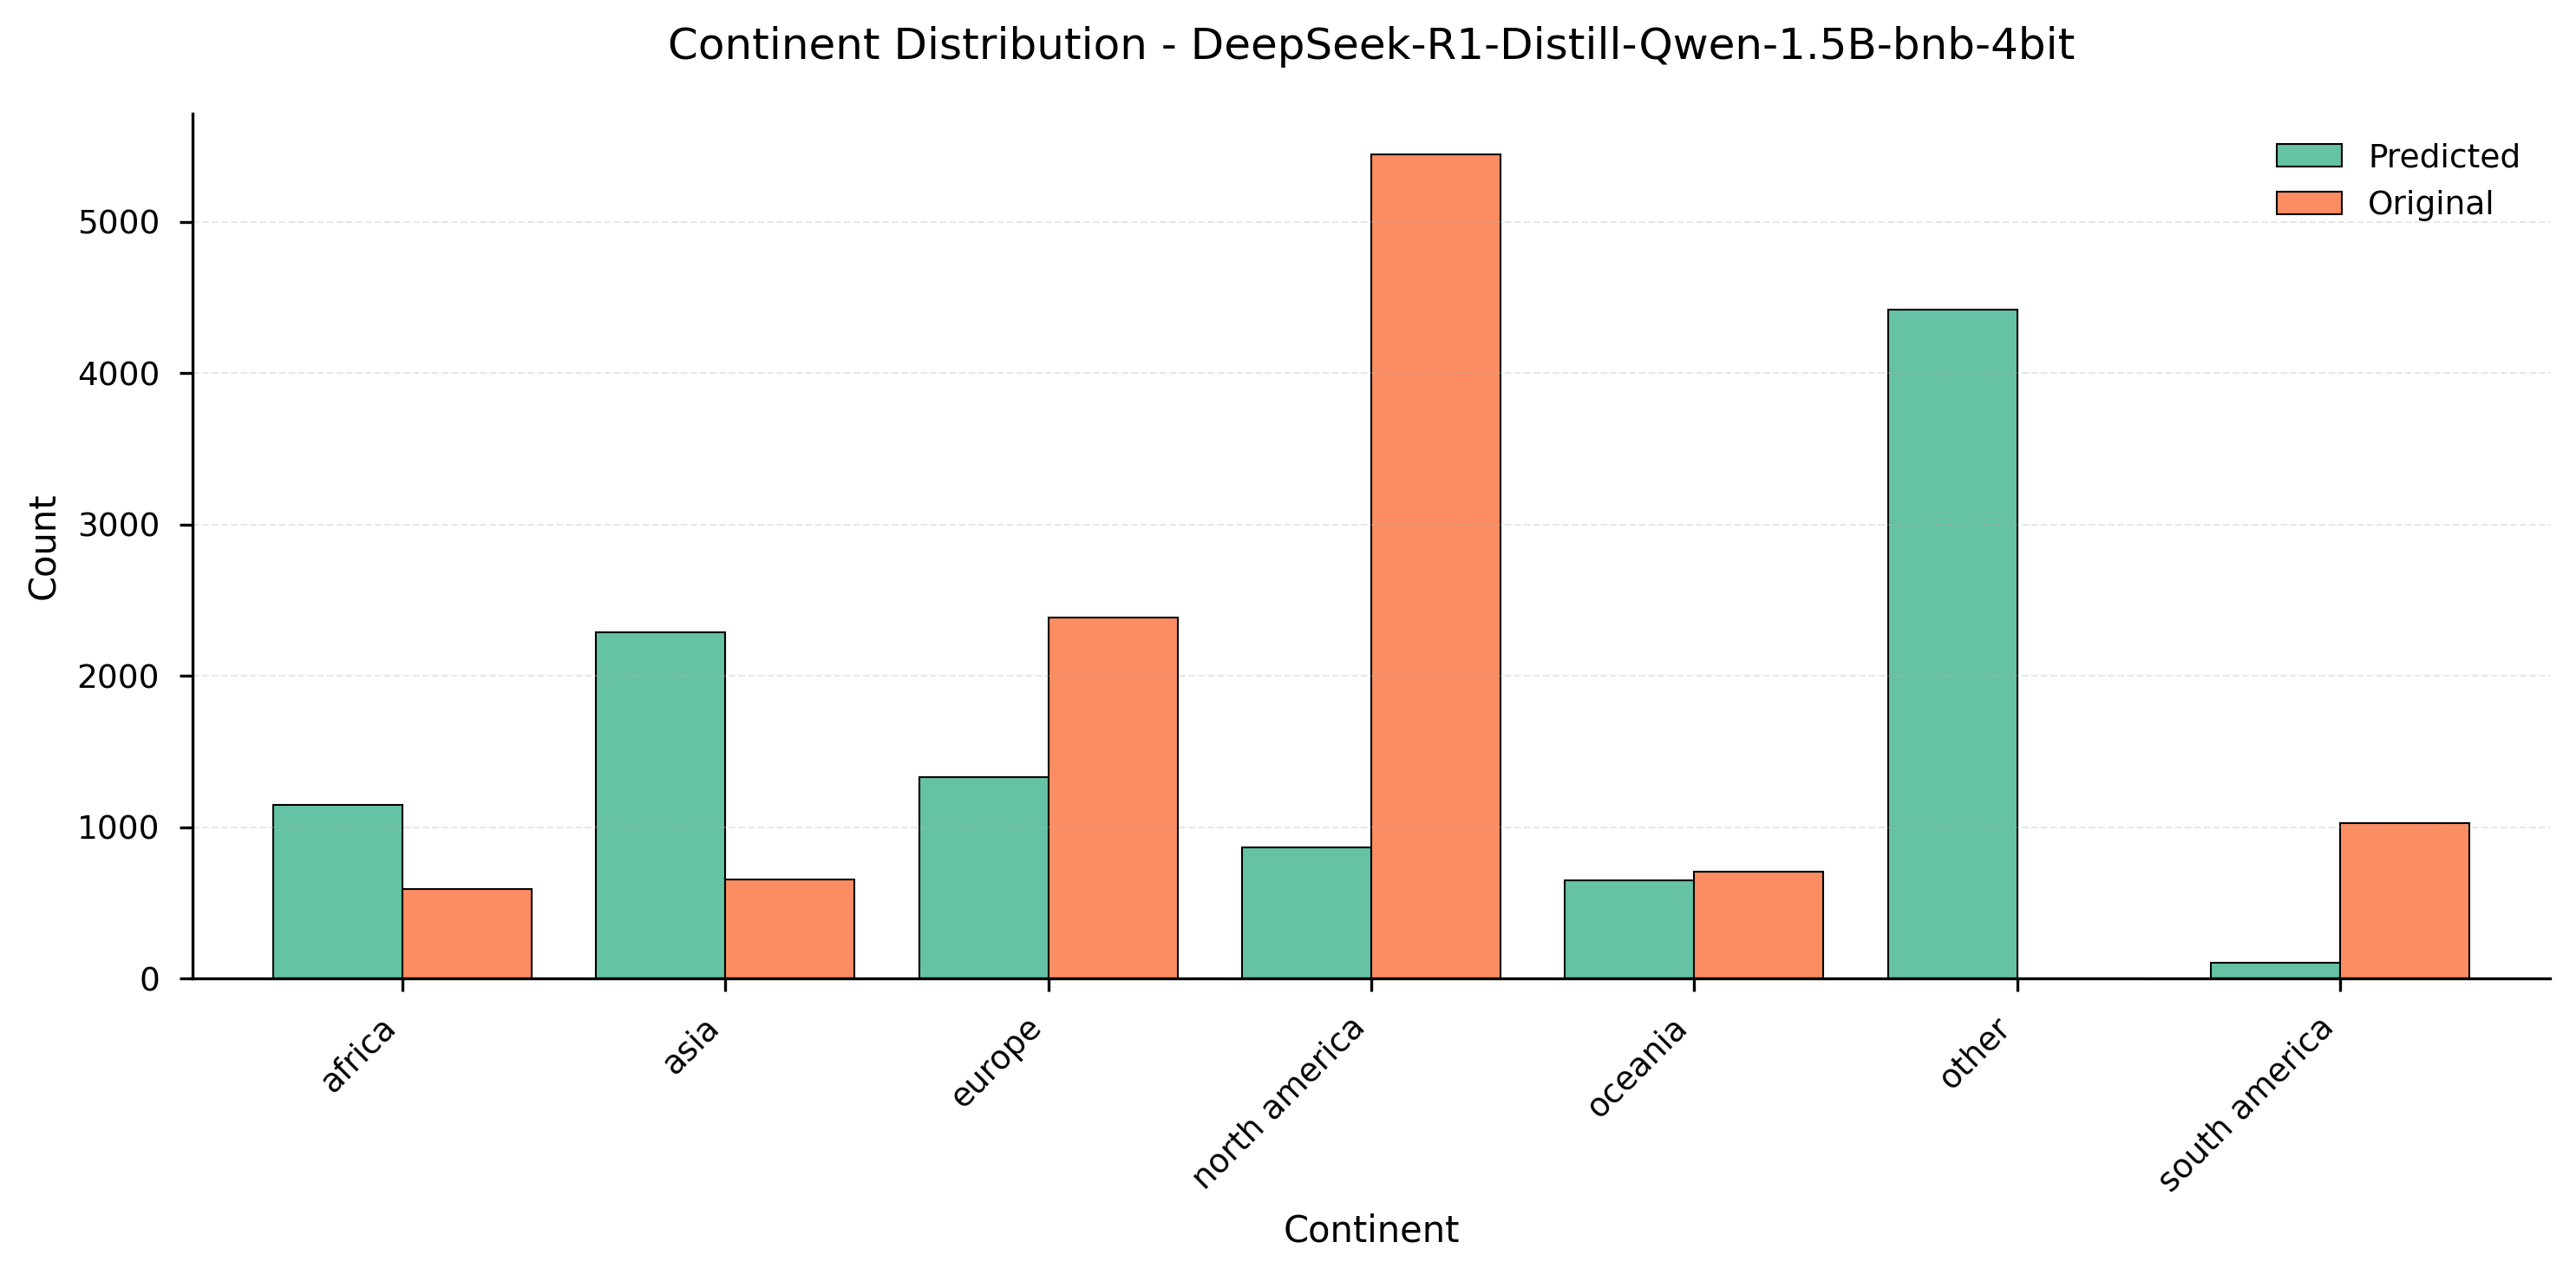

gender accuracy 	33.3642% 



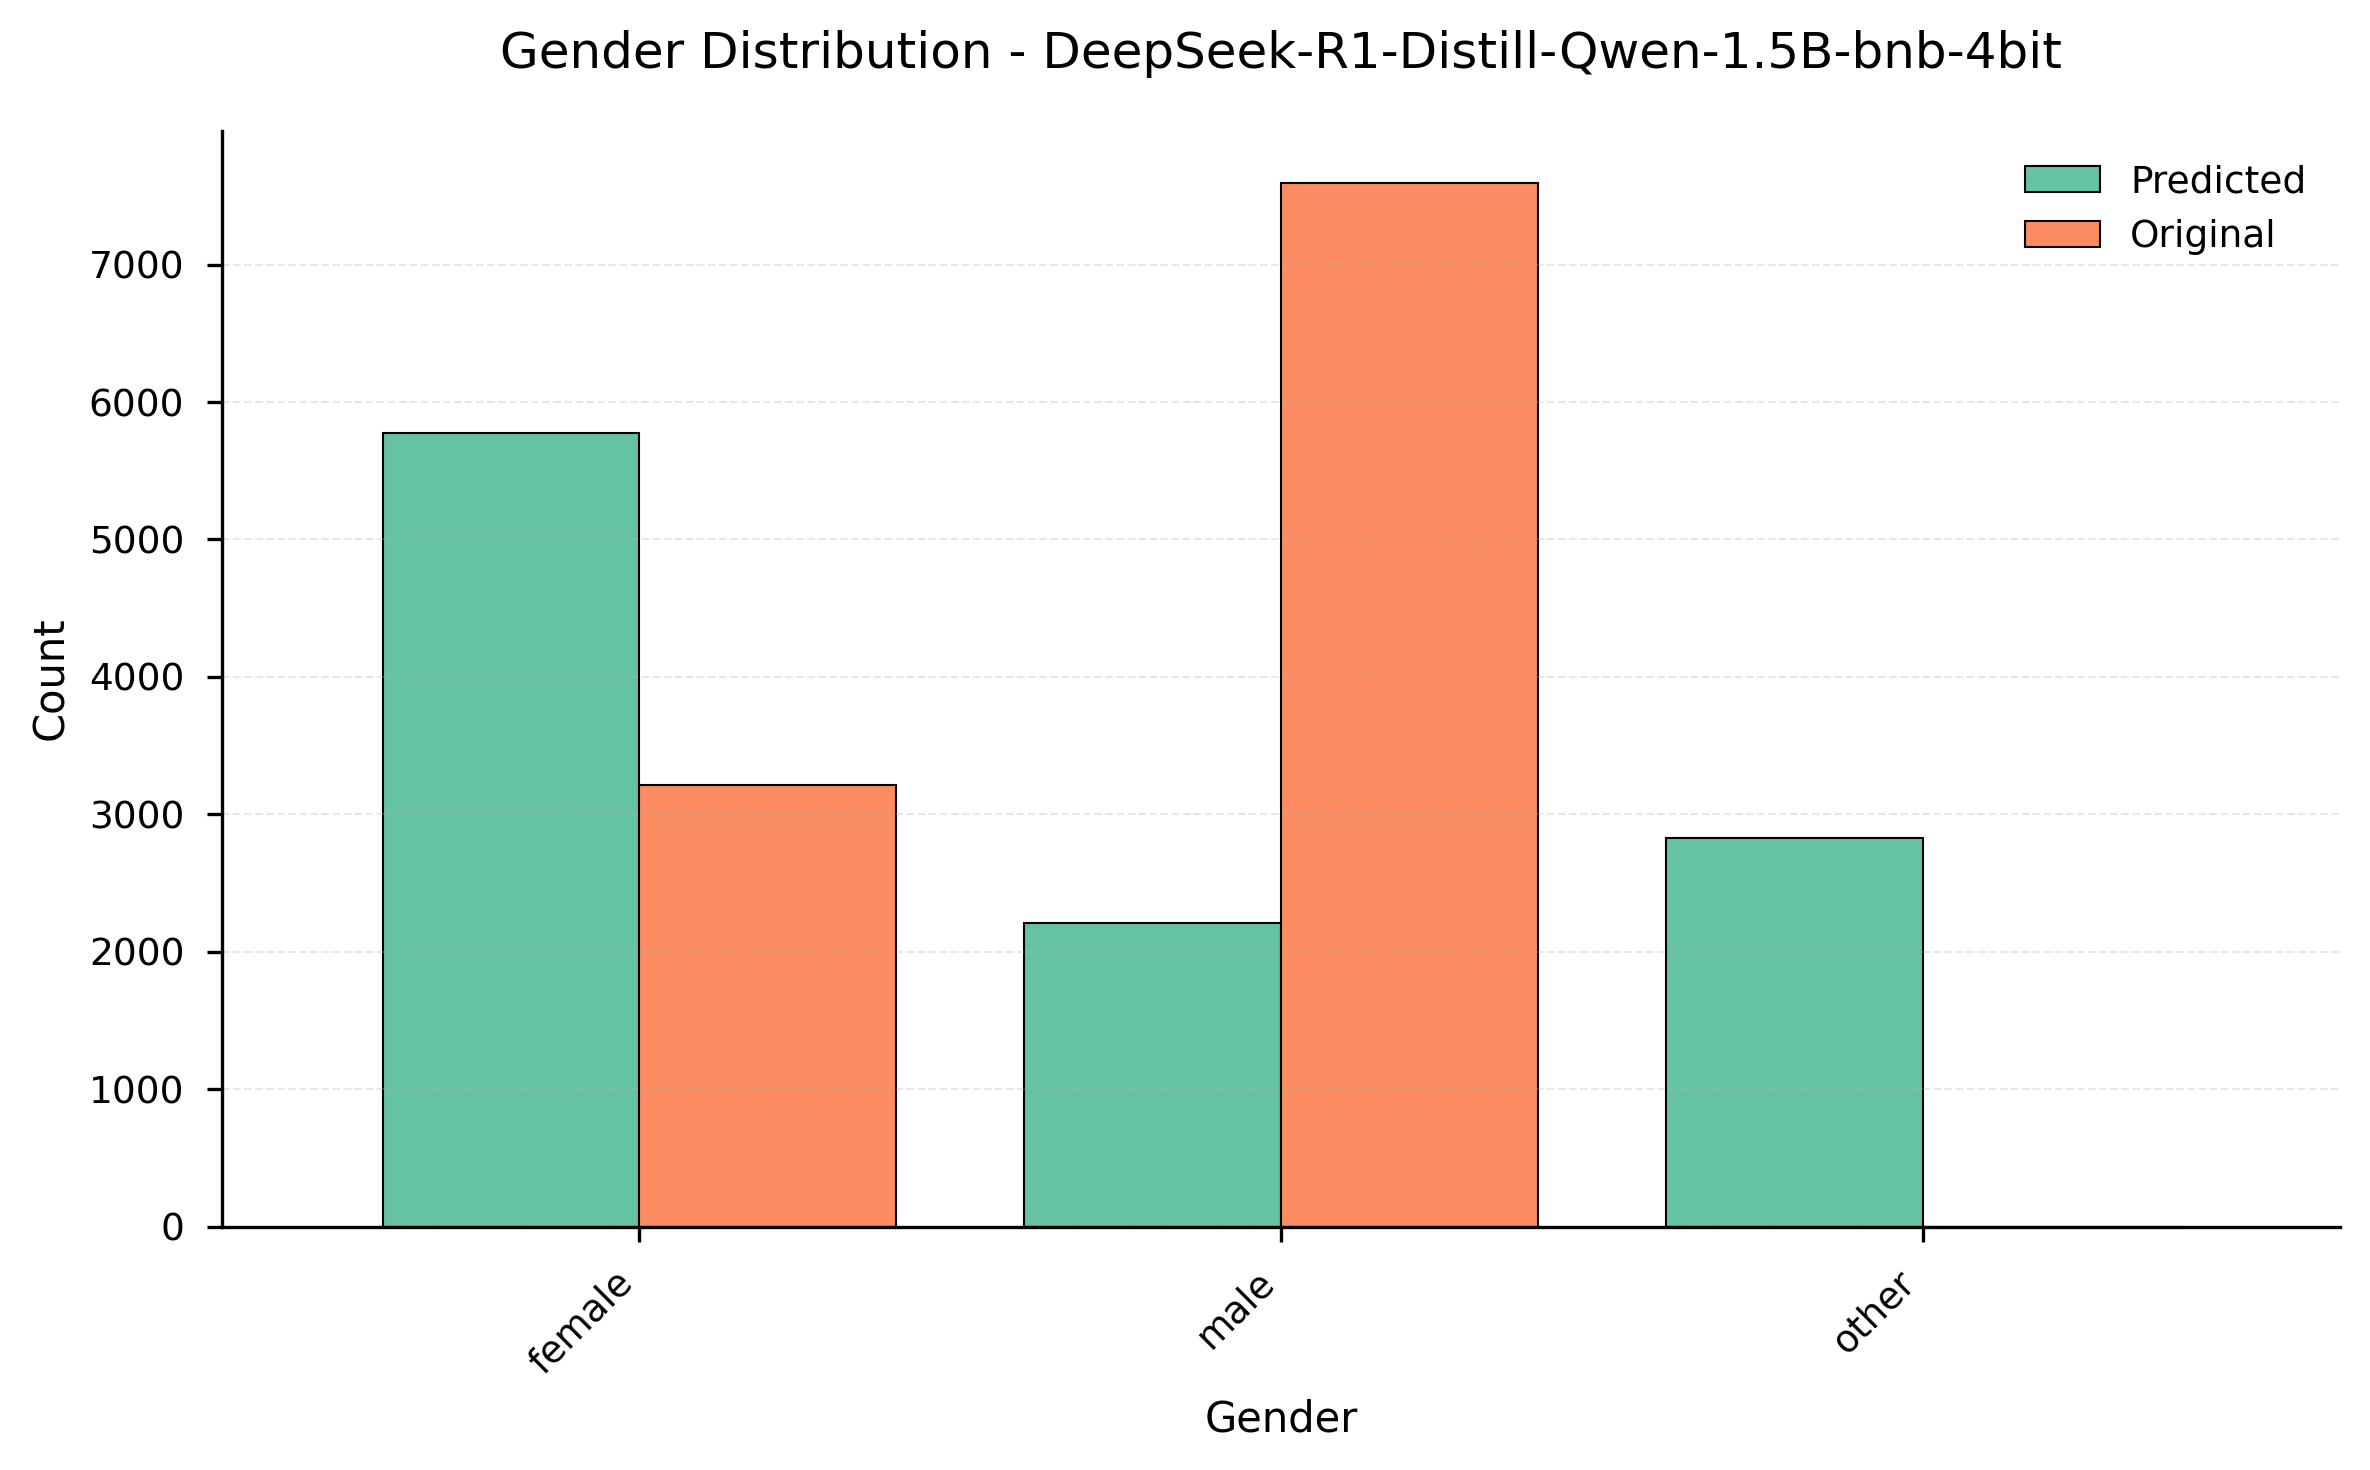

In [6]:
plot_continent_comparison(df_deepseek1_5_quantized, "DeepSeek-R1-Distill-Qwen-1.5B-bnb-4bit")
plot_gender_comparison(df_deepseek1_5_quantized, "DeepSeek-R1-Distill-Qwen-1.5B-bnb-4bit")

In [21]:
df_deepseek1_5_quantized.to_csv("DeepSeek-R1-Distill-Qwen-1.5B-bnb-4bit/DeepSeek-R1-Distill-Qwen-1.5B-bnb-4bit_gender_classification_merged.csv", index=False)